# CSI First Test Analysis - Validation of Initial Recordings
**Project:** Device-Free Wi-Fi Sensing with CSI on ESP32-S3  
**Author:** Warley Xavier
**Course:** PFC I - Control and Automation Engineering - UFMG 2026/1

---
> **Purpose of this notebook:** Validate the first two pilot recording sessions (one *empty* room,  
> one *occupied* room) and decide whether the project can advance to full dataset collection.  
>
> **Input per session:** a `.csv` data file **+** its companion `_meta.json` file,  
> both generated by `csi_collector_v2`.  
>
> **Outputs:** 10 high-resolution plots saved to `./outputs/` and an automated  
> viability verdict printed in the final cell.


## 1 - Configuration

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
from pathlib import Path
from datetime import datetime
from scipy import signal as sp_signal

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.dpi": 200,
    "font.family": "DejaVu Sans",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# -------------------------------------------------------------------
# SET THESE PATHS BEFORE RUNNING
# Each session needs its .csv file.
# The companion _meta.json is loaded automatically if it exists
# alongside the CSV with the expected naming convention; you can
# also supply it explicitly via PATH_META_*.
# -------------------------------------------------------------------

# Base directory for collector outputs
# Locate repo root regardless of where Jupyter was launched from
_p = Path.cwd()
for PROJECT_ROOT in [_p, _p.parent, _p.parent.parent]:
    if (PROJECT_ROOT / 'requirements.txt').exists():
        break

DATA_DIR     = PROJECT_ROOT / 'data' / '01_raw' / 'first_test'

PATH_CSV_A   = str(DATA_DIR / "session_PLA_empty_20260405_1847.csv")
PATH_META_A  = None   # auto-detect: same folder, same stem + _meta.json

PATH_CSV_B   = str(DATA_DIR / "session_PLB_occupied_still_20260405_1850.csv")
PATH_META_B  = None   # auto-detect

# Output directory for saved figures
OUTPUT_DIR   = PROJECT_ROOT / 'outputs' / 'first_test'
DPI          = 200           # figure save resolution

# Nominal TX ICMP rate (Hz) - used as fallback when JSON is unavailable
NOMINAL_RATE_HZ = 30

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR.resolve()}")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")


Data directory: /home/xavier/code/wifi-csi-presence-detection/first_test/data
Output directory: /home/xavier/code/wifi-csi-presence-detection/first_test/outputs


## 2 - Parsing & Utility Functions

In [2]:
# --- Timestamp helpers -------------------------------------------------------

TS_HOST_FMT = "%Y%m%dT%H%M%S.%f"   # format used by csi_collector_v2

def parse_ts_host(s: str) -> pd.Timestamp:
    """Convert a timestamp_host string to a tz-naive pandas Timestamp."""
    return pd.to_datetime(s, format=TS_HOST_FMT)

def iso_to_ts(s: str) -> pd.Timestamp:
    """Convert an ISO-8601 string (possibly with UTC offset) to tz-naive UTC Timestamp."""
    return pd.Timestamp(s).tz_localize(None) if pd.Timestamp(s).tzinfo is None \
           else pd.Timestamp(s).tz_convert(None)

# --- CSI parsing -------------------------------------------------------------

def parse_csi_array(data_str: str) -> np.ndarray | None:
    """Parse the 'data' column (JSON array string) into an int8 numpy array."""
    try:
        return np.array(json.loads(data_str), dtype=np.int8)
    except Exception:
        return None

def raw_to_complex(raw: np.ndarray) -> np.ndarray:
    """
    Convert a raw int8 array to complex subcarrier values.
    ESP32 CSI format: [imag_0, real_0, imag_1, real_1, ...]
    """
    return raw[1::2].astype(np.float32) + 1j * raw[0::2].astype(np.float32)

def detect_valid_subcarriers(amp_matrix: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """
    Return a boolean mask of non-null subcarriers.
    Guard bands and DC subcarriers have near-zero amplitude throughout the session.
    """
    return amp_matrix.mean(axis=0) > threshold

# --- JSON metadata loader ----------------------------------------------------

def find_meta_json(csv_path: str) -> str | None:
    """Auto-detect the companion _meta.json from a CSV path."""
    stem = Path(csv_path).stem          # e.g. session_A_empty_20260405_1731
    candidate = Path(csv_path).with_name(stem + "_meta.json")
    return str(candidate) if candidate.exists() else None

def load_meta(json_path: str | None) -> dict | None:
    if json_path is None:
        return None
    try:
        with open(json_path, encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None

# --- Main session loader -----------------------------------------------------

def load_session(csv_path: str, meta_path: str | None = None) -> dict | None:
    """
    Load and process a v2 CSI session.

    Returns a dictionary with:
      df            - cleaned DataFrame (one row per packet)
      time_s        - relative time in seconds from the first packet
      time_abs      - absolute pandas Timestamps (timestamp_host column)
      csi_complex   - complex CSI matrix (T x Ns)
      csi_amp       - amplitude matrix (T x Ns)
      csi_phase     - phase matrix (T x Ns)
      valid_mask    - boolean mask of non-null subcarriers
      meta          - parsed JSON metadata dict (or None)
      label         - session label string
      eff_rate_hz   - median effective sample rate
      dt            - inter-packet intervals (seconds)
      t1 / t2       - condition window boundaries as pd.Timestamp (or None)
    """
    csv_path = str(csv_path)
    if meta_path is None:
        meta_path = find_meta_json(csv_path)

    meta  = load_meta(meta_path)
    label = "unknown"

    if meta:
        label = meta.get("session", {}).get("label", "unknown")
        print(f"[{label}] JSON metadata loaded from: {Path(meta_path).name}")
    else:
        # Infer label from filename (session_ID_LABEL_DATE_TIME.csv)
        parts = Path(csv_path).stem.split("_")
        if len(parts) >= 3:
            label = "_".join(parts[2:-2]) if len(parts) > 4 else parts[2]
        print(f"[{label}] No JSON found - label inferred from filename.")

    print(f"[{label}] Loading CSV: {Path(csv_path).name}")

    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"  [ERROR] File not found: {csv_path}")
        return None

    df = df[df["type"] == "CSI_DATA"].copy().reset_index(drop=True)
    print(f"  {len(df)} packets read")

    # Parse host timestamps
    df["time_abs"] = df["timestamp_host"].apply(parse_ts_host)
    df = df.sort_values("time_abs").reset_index(drop=True)

    # Relative time (seconds from first packet)
    t0_abs = df["time_abs"].iloc[0]
    df["time_s"] = (df["time_abs"] - t0_abs).dt.total_seconds()

    # Parse CSI arrays
    df["csi_raw"] = df["data"].apply(parse_csi_array)
    n_invalid = df["csi_raw"].isna().sum()
    df = df[df["csi_raw"].notna()].reset_index(drop=True)
    if n_invalid:
        print(f"  [WARNING] {n_invalid} packets dropped (parse error)")

    csi_len = int(df["csi_raw"].iloc[0].shape[0])
    n_sub   = csi_len // 2
    df = df[df["csi_raw"].apply(len) == csi_len].reset_index(drop=True)
    print(f"  CSI vector length: {csi_len} -> {n_sub} complex subcarriers")

    csi_complex = np.stack(df["csi_raw"].apply(raw_to_complex).values)
    csi_amp     = np.abs(csi_complex)
    csi_phase   = np.angle(csi_complex)
    valid_mask  = detect_valid_subcarriers(csi_amp)
    n_valid     = valid_mask.sum()

    dt       = np.diff(df["time_s"].values)
    eff_rate = 1.0 / np.median(dt)
    duration = df["time_s"].iloc[-1]

    print(f"  Valid subcarriers: {n_valid}/{n_sub}")
    print(f"  Duration: {duration:.2f} s  |  Effective rate: {eff_rate:.1f} Hz")

    # Ground-truth condition window (t1 -> t2) from JSON
    t1 = t2 = None
    if meta and "timing" in meta:
        try:
            t1_iso = meta["timing"].get("t1_condition_start")
            t2_iso = meta["timing"].get("t2_condition_end")
            if t1_iso:
                t1 = iso_to_ts(t1_iso)
            if t2_iso:
                t2 = iso_to_ts(t2_iso)
        except Exception:
            pass
    if t1 and t2 and t1 != t2:
        active_s = (t2 - t1).total_seconds()
        print(f"  Condition window (t1->t2): {active_s:.0f} s")
    else:
        t1 = t2 = None   # treat as unavailable
        print(f"  Condition window: not available (t1/t2 not set in JSON)")

    return {
        "label":       label,
        "csv_path":    csv_path,
        "df":          df,
        "time_s":      df["time_s"].values,
        "time_abs":    df["time_abs"],
        "csi_complex": csi_complex,
        "csi_amp":     csi_amp,
        "csi_phase":   csi_phase,
        "valid_mask":  valid_mask,
        "n_sub":       n_sub,
        "n_valid":     n_valid,
        "duration_s":  duration,
        "eff_rate_hz": eff_rate,
        "dt":          dt,
        "meta":        meta,
        "t1":          t1,
        "t2":          t2,
        "t0_abs":      t0_abs,
    }


## 3 - Load Sessions

In [3]:
sess_A = load_session(PATH_CSV_A, PATH_META_A)
sess_B = load_session(PATH_CSV_B, PATH_META_B)

sessions = {k: v for k, v in {"A": sess_A, "B": sess_B}.items() if v is not None}
if not sessions:
    raise RuntimeError("No sessions loaded. Check PATH_CSV_A and PATH_CSV_B.")

sess_list = list(sessions.values())

# Shared valid-subcarrier mask (intersection of both sessions)
if len(sess_list) == 2:
    valid_shared = sess_list[0]["valid_mask"] & sess_list[1]["valid_mask"]
else:
    valid_shared = sess_list[0]["valid_mask"]

sub_indices   = np.where(valid_shared)[0]
n_valid_shared = valid_shared.sum()
print(f"\nShared valid subcarriers: {n_valid_shared}")

# Display nominal ICMP rate from JSON (if available)
for key, s in sessions.items():
    if s["meta"]:
        icmp_hz = s["meta"].get("setup", {}).get("wifi", {}).get("icmp_rate_hz")
        if icmp_hz:
            print(f"Session {key} - configured ICMP rate (TX): {icmp_hz} Hz")


[empty] JSON metadata loaded from: session_PLA_empty_20260405_1847_meta.json
[empty] Loading CSV: session_PLA_empty_20260405_1847.csv
  1735 packets read
  CSI vector length: 384 -> 192 complex subcarriers
  Valid subcarriers: 166/192
  Duration: 59.98 s  |  Effective rate: 29.4 Hz
  Condition window: not available (t1/t2 not set in JSON)
[occupied_still] JSON metadata loaded from: session_PLB_occupied_still_20260405_1850_meta.json
[occupied_still] Loading CSV: session_PLB_occupied_still_20260405_1850.csv
  1736 packets read
  CSI vector length: 384 -> 192 complex subcarriers
  Valid subcarriers: 161/192
  Duration: 59.97 s  |  Effective rate: 29.4 Hz
  Condition window: not available (t1/t2 not set in JSON)

Shared valid subcarriers: 161
Session A - configured ICMP rate (TX): 30 Hz
Session B - configured ICMP rate (TX): 30 Hz


## 4 - Session Metadata

In [4]:
def print_session_summary(key: str, s: dict) -> None:
    print(f"{'='*62}")
    print(f"  SESSION {key}  |  Label: {s['label'].upper()}")
    print(f"{'='*62}")
    print(f"  CSV file     : {Path(s['csv_path']).name}")
    print(f"  Packets      : {len(s['df'])}")
    print(f"  Duration     : {s['duration_s']:.1f} s")
    print(f"  Eff. rate    : {s['eff_rate_hz']:.1f} Hz")
    print(f"  Valid sub.   : {s['n_valid']}/{s['n_sub']}")

    if s["t1"] and s["t2"]:
        print(f"  Cond. window : {s['t1'].strftime('%H:%M:%S')} -> "
              f"{s['t2'].strftime('%H:%M:%S')}  "
              f"({(s['t2']-s['t1']).total_seconds():.0f} s)")
    else:
        print(f"  Cond. window : not set in JSON")

    m = s["meta"]
    if m:
        env  = m.get("environment", {})
        wifi = m.get("setup", {}).get("wifi", {})
        room = m.get("setup", {}).get("room", {})
        nodes = m.get("setup", {}).get("nodes", {})
        print(f"  -- Environment --------------------------------------")
        print(f"  Temperature  : {env.get('temperature_C', 'N/A')} C")
        print(f"  Visible nets : {env.get('visible_wifi_networks', 'N/A')}")
        print(f"  Door/Window  : {env.get('door_state','N/A')} / {env.get('window_state','N/A')}")
        print(f"  Notes        : {env.get('free_notes') or 'none'}")
        print(f"  -- Wi-Fi setup --------------------------------------")
        print(f"  Channel      : {wifi.get('channel','N/A')}  |  BW: {wifi.get('bandwidth_mhz','N/A')} MHz")
        print(f"  Protocol     : {wifi.get('protocol','N/A')}")
        print(f"  ICMP rate    : {wifi.get('icmp_rate_hz','N/A')} Hz")
        dist = nodes.get("tx_rx_los_distance_m", "N/A")
        print(f"  TX-RX dist.  : {dist} m")
    print()

for key, s in sessions.items():
    print_session_summary(key, s)


  SESSION A  |  Label: EMPTY
  CSV file     : session_PLA_empty_20260405_1847.csv
  Packets      : 1735
  Duration     : 60.0 s
  Eff. rate    : 29.4 Hz
  Valid sub.   : 166/192
  Cond. window : not set in JSON
  -- Environment --------------------------------------
  Temperature  : None C
  Visible nets : None
  Door/Window  : closed / closed
  Notes        : none
  -- Wi-Fi setup --------------------------------------
  Channel      : 6  |  BW: 20 MHz
  Protocol     : 802.11n HT20
  ICMP rate    : 30 Hz
  TX-RX dist.  : 2.0 m

  SESSION B  |  Label: OCCUPIED_STILL
  CSV file     : session_PLB_occupied_still_20260405_1850.csv
  Packets      : 1736
  Duration     : 60.0 s
  Eff. rate    : 29.4 Hz
  Valid sub.   : 161/192
  Cond. window : not set in JSON
  -- Environment --------------------------------------
  Temperature  : None C
  Visible nets : None
  Door/Window  : closed / closed
  Notes        : none
  -- Wi-Fi setup --------------------------------------
  Channel      : 6  |  

## 5 - Automated Quality Report

In [5]:
LABEL_COLORS = {
    "empty":           "#2196F3",
    "occupied_still":  "#F44336",
    "occupied_moving": "#FF9800",
    "unknown":         "#9E9E9E",
}

def get_color(label: str) -> str:
    for key, color in LABEL_COLORS.items():
        if key in label:
            return color
    return "#607D8B"

def get_nominal_rate(s: dict) -> float:
    """Read nominal TX rate from JSON, fall back to module-level constant."""
    if s["meta"]:
        r = s["meta"].get("setup", {}).get("wifi", {}).get("icmp_rate_hz")
        if r:
            return float(r)
    return NOMINAL_RATE_HZ

def quality_report(s: dict) -> dict:
    df   = s["df"]
    dt   = s["dt"]
    rate = s["eff_rate_hz"]
    nom  = get_nominal_rate(s)

    dt_nom   = 1.0 / nom
    gaps     = dt[dt > 2.5 * dt_nom]
    lost_est = max(0, int(np.round(gaps.sum() / dt_nom)) - len(gaps))
    exp_pkts = int(np.round(s["duration_s"] * nom))
    loss_pct = 100 * lost_est / max(exp_pkts, 1)

    rssi  = df["rssi"].values.astype(float)
    amp_v = s["csi_amp"][:, s["valid_mask"]]

    return {
        "label":         s["label"],
        "duration_s":    s["duration_s"],
        "pkt_received":  len(df),
        "pkt_expected":  exp_pkts,
        "pkt_lost_est":  lost_est,
        "loss_pct":      loss_pct,
        "rate_eff_hz":   rate,
        "nominal_hz":    nom,
        "jitter_ms":     dt.std() * 1000,
        "rssi_mean":     rssi.mean(),
        "rssi_std":      rssi.std(),
        "rssi_min":      rssi.min(),
        "rssi_max":      rssi.max(),
        "amp_mean":      amp_v.mean(),
        "amp_std":       amp_v.std(),
        "n_valid_sub":   s["n_valid"],
    }

reports   = [quality_report(s) for s in sessions.values()]
df_report = pd.DataFrame(reports).set_index("label")

rename = {
    "duration_s":   "Duration (s)",
    "pkt_received": "Packets received",
    "pkt_expected": "Packets expected",
    "pkt_lost_est": "Lost packets (est.)",
    "loss_pct":     "Packet loss (%)",
    "rate_eff_hz":  "Effective rate (Hz)",
    "nominal_hz":   "Nominal rate (Hz)",
    "jitter_ms":    "Jitter (ms)",
    "rssi_mean":    "RSSI mean (dBm)",
    "rssi_std":     "RSSI std (dBm)",
    "rssi_min":     "RSSI min (dBm)",
    "rssi_max":     "RSSI max (dBm)",
    "n_valid_sub":  "Valid subcarriers",
    "amp_mean":     "CSI amplitude mean",
    "amp_std":      "CSI amplitude std",
}
print(df_report[list(rename.keys())].rename(columns=rename).T.to_string(float_format="%.2f"))
print()

print("-- VIABILITY CRITERIA -----------------------------------------------")
for r in reports:
    checks = []
    checks.append(("loss_pct < 5 %",
                   r["loss_pct"] < 5,
                   f"packet loss = {r['loss_pct']:.1f} %"))
    rate_err = abs(r["rate_eff_hz"] - r["nominal_hz"]) / r["nominal_hz"]
    checks.append(("rate within +/-10 %",
                   rate_err < 0.10,
                   f"eff. = {r['rate_eff_hz']:.1f} Hz, nominal = {r['nominal_hz']:.0f} Hz"))
    checks.append(("RSSI std < 5 dBm",
                   r["rssi_std"] < 5,
                   f"RSSI std = {r['rssi_std']:.2f} dBm"))
    checks.append((">= 40 valid subcarriers",
                   r["n_valid_sub"] >= 40,
                   f"{r['n_valid_sub']} valid subcarriers"))

    print(f"\n[{r['label'].upper()}]")
    for name, ok, detail in checks:
        sym = "[pass]" if ok else "[fail]"
        print(f"  {sym} {name:<28} {detail}")


label                 empty  occupied_still
Duration (s)          59.98           59.97
Packets received    1735.00         1736.00
Packets expected    1799.00         1799.00
Lost packets (est.)    0.00            0.00
Packet loss (%)        0.00            0.00
Effective rate (Hz)   29.41           29.42
Nominal rate (Hz)     30.00           30.00
Jitter (ms)            5.05            4.78
RSSI mean (dBm)      -30.00          -42.85
RSSI std (dBm)         0.02            1.28
RSSI min (dBm)       -31.00          -47.00
RSSI max (dBm)       -30.00          -40.00
Valid subcarriers    166.00          161.00
CSI amplitude mean    34.88           10.49
CSI amplitude std     20.87            7.72

-- VIABILITY CRITERIA -----------------------------------------------

[EMPTY]
  [pass] loss_pct < 5 %               packet loss = 0.0 %
  [pass] rate within +/-10 %          eff. = 29.4 Hz, nominal = 30 Hz
  [pass] RSSI std < 5 dBm             RSSI std = 0.02 dBm
  [pass] >= 40 valid subcarrie

## 6 - Visualizations

### 6.1 Recording Timeline (t0 → t1 → t2 → t3)

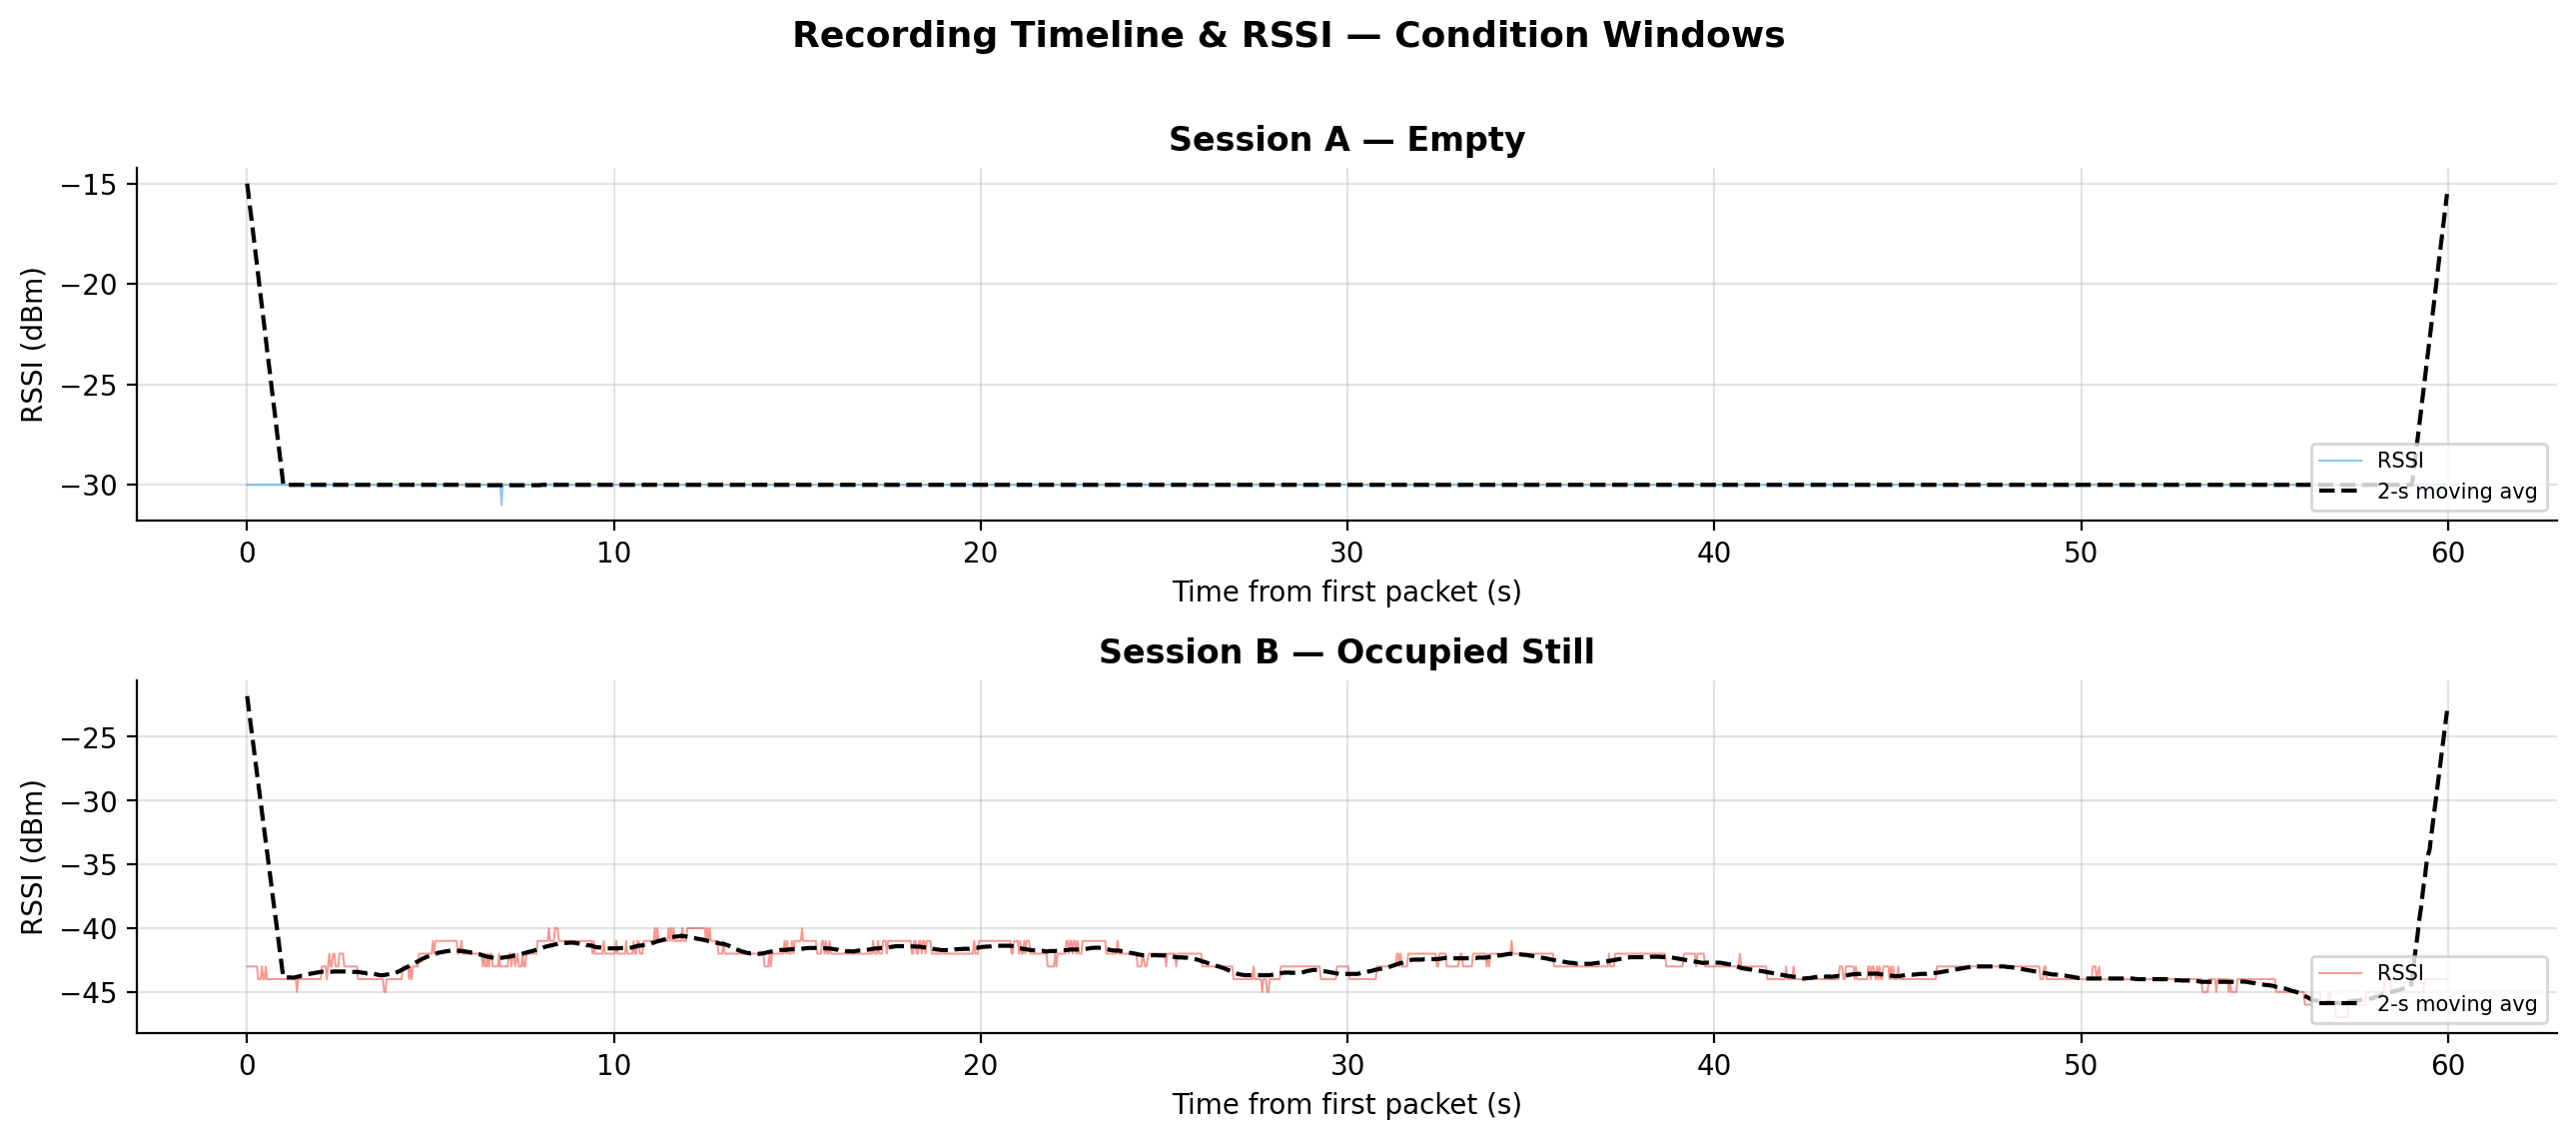

Saved: ./outputs/01_recording_timeline.png


In [6]:
fig, axes = plt.subplots(
    len(sessions), 1,
    figsize=(13, 2.8 * len(sessions)),
    sharex=False, squeeze=False
)

for ax, (key, s) in zip(axes[:, 0], sessions.items()):
    t     = s["time_s"]
    rssi  = s["df"]["rssi"].values.astype(float)
    color = get_color(s["label"])

    ax.plot(t, rssi, color=color, lw=0.7, alpha=0.55, label="RSSI")
    win = max(1, int(s["eff_rate_hz"] * 2))
    smooth = np.convolve(rssi, np.ones(win)/win, mode="same")
    ax.plot(t, smooth, color="black", lw=1.5, ls="--", label=f"2-s moving avg")

    # Mark t1 / t2 if available
    if s["t1"] and s["t2"]:
        t1_s = (s["t1"] - s["t0_abs"]).total_seconds()
        t2_s = (s["t2"] - s["t0_abs"]).total_seconds()
        ax.axvspan(t1_s, t2_s, color=color, alpha=0.12, label="Condition window (t1→t2)")
        ax.axvline(t1_s, color="green",  lw=1.5, ls="--", label=f"t1 = {s['t1'].strftime('%H:%M:%S')}")
        ax.axvline(t2_s, color="crimson", lw=1.5, ls="--", label=f"t2 = {s['t2'].strftime('%H:%M:%S')}")

    ax.set_title(f"Session {key} - {s['label'].replace('_', ' ').title()}",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("RSSI (dBm)")
    ax.set_xlabel("Time from first packet (s)")
    ax.legend(loc="lower right", fontsize=7.5)

plt.suptitle("Recording Timeline & RSSI - Condition Windows", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
path_out = os.path.join(OUTPUT_DIR, "01_recording_timeline.png")
plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {path_out}")


### 6.2 Packet Inter-Arrival Time (sampling-rate validation)

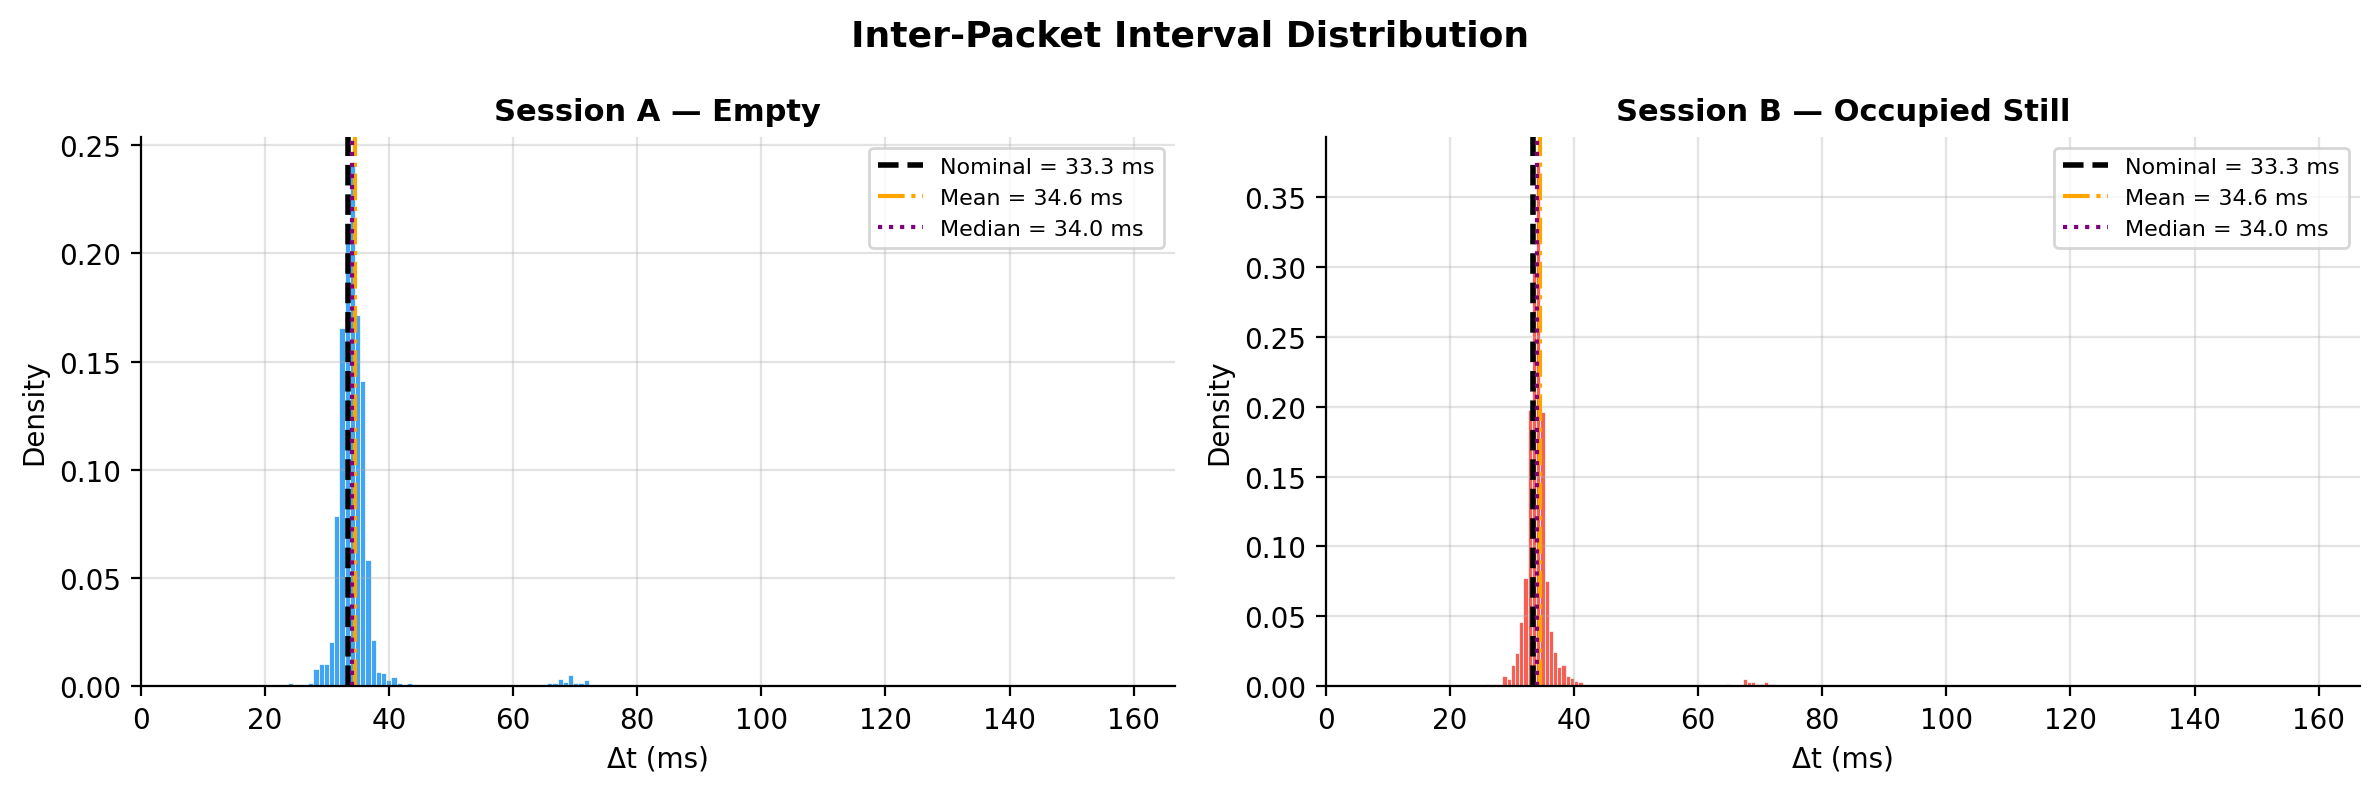

Saved: ./outputs/02_packet_interval.png


In [7]:
fig, axes = plt.subplots(
    1, len(sessions),
    figsize=(6 * len(sessions), 4),
    sharey=False, squeeze=False
)

for ax, (key, s) in zip(axes[0], sessions.items()):
    dt_ms   = s["dt"] * 1000
    nom_ms  = 1000 / get_nominal_rate(s)
    color   = get_color(s["label"])

    ax.hist(dt_ms, bins=70, color=color, edgecolor="white",
            linewidth=0.3, alpha=0.85, density=True)
    ax.axvline(nom_ms,       color="black",  lw=2.0, ls="--",
               label=f"Nominal = {nom_ms:.1f} ms")
    ax.axvline(dt_ms.mean(), color="orange", lw=1.5, ls="-.",
               label=f"Mean = {dt_ms.mean():.1f} ms")
    ax.axvline(np.median(dt_ms), color="purple", lw=1.5, ls=":",
               label=f"Median = {np.median(dt_ms):.1f} ms")

    ax.set_title(f"Session {key} - {s['label'].replace('_',' ').title()}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Δt (ms)")
    ax.set_ylabel("Density")
    ax.set_xlim(0, nom_ms * 5)
    ax.legend(fontsize=8)

plt.suptitle("Inter-Packet Interval Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
path_out = os.path.join(OUTPUT_DIR, "02_packet_interval.png")
plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {path_out}")


### 6.3 CSI Amplitude Heatmap (subcarriers × time)

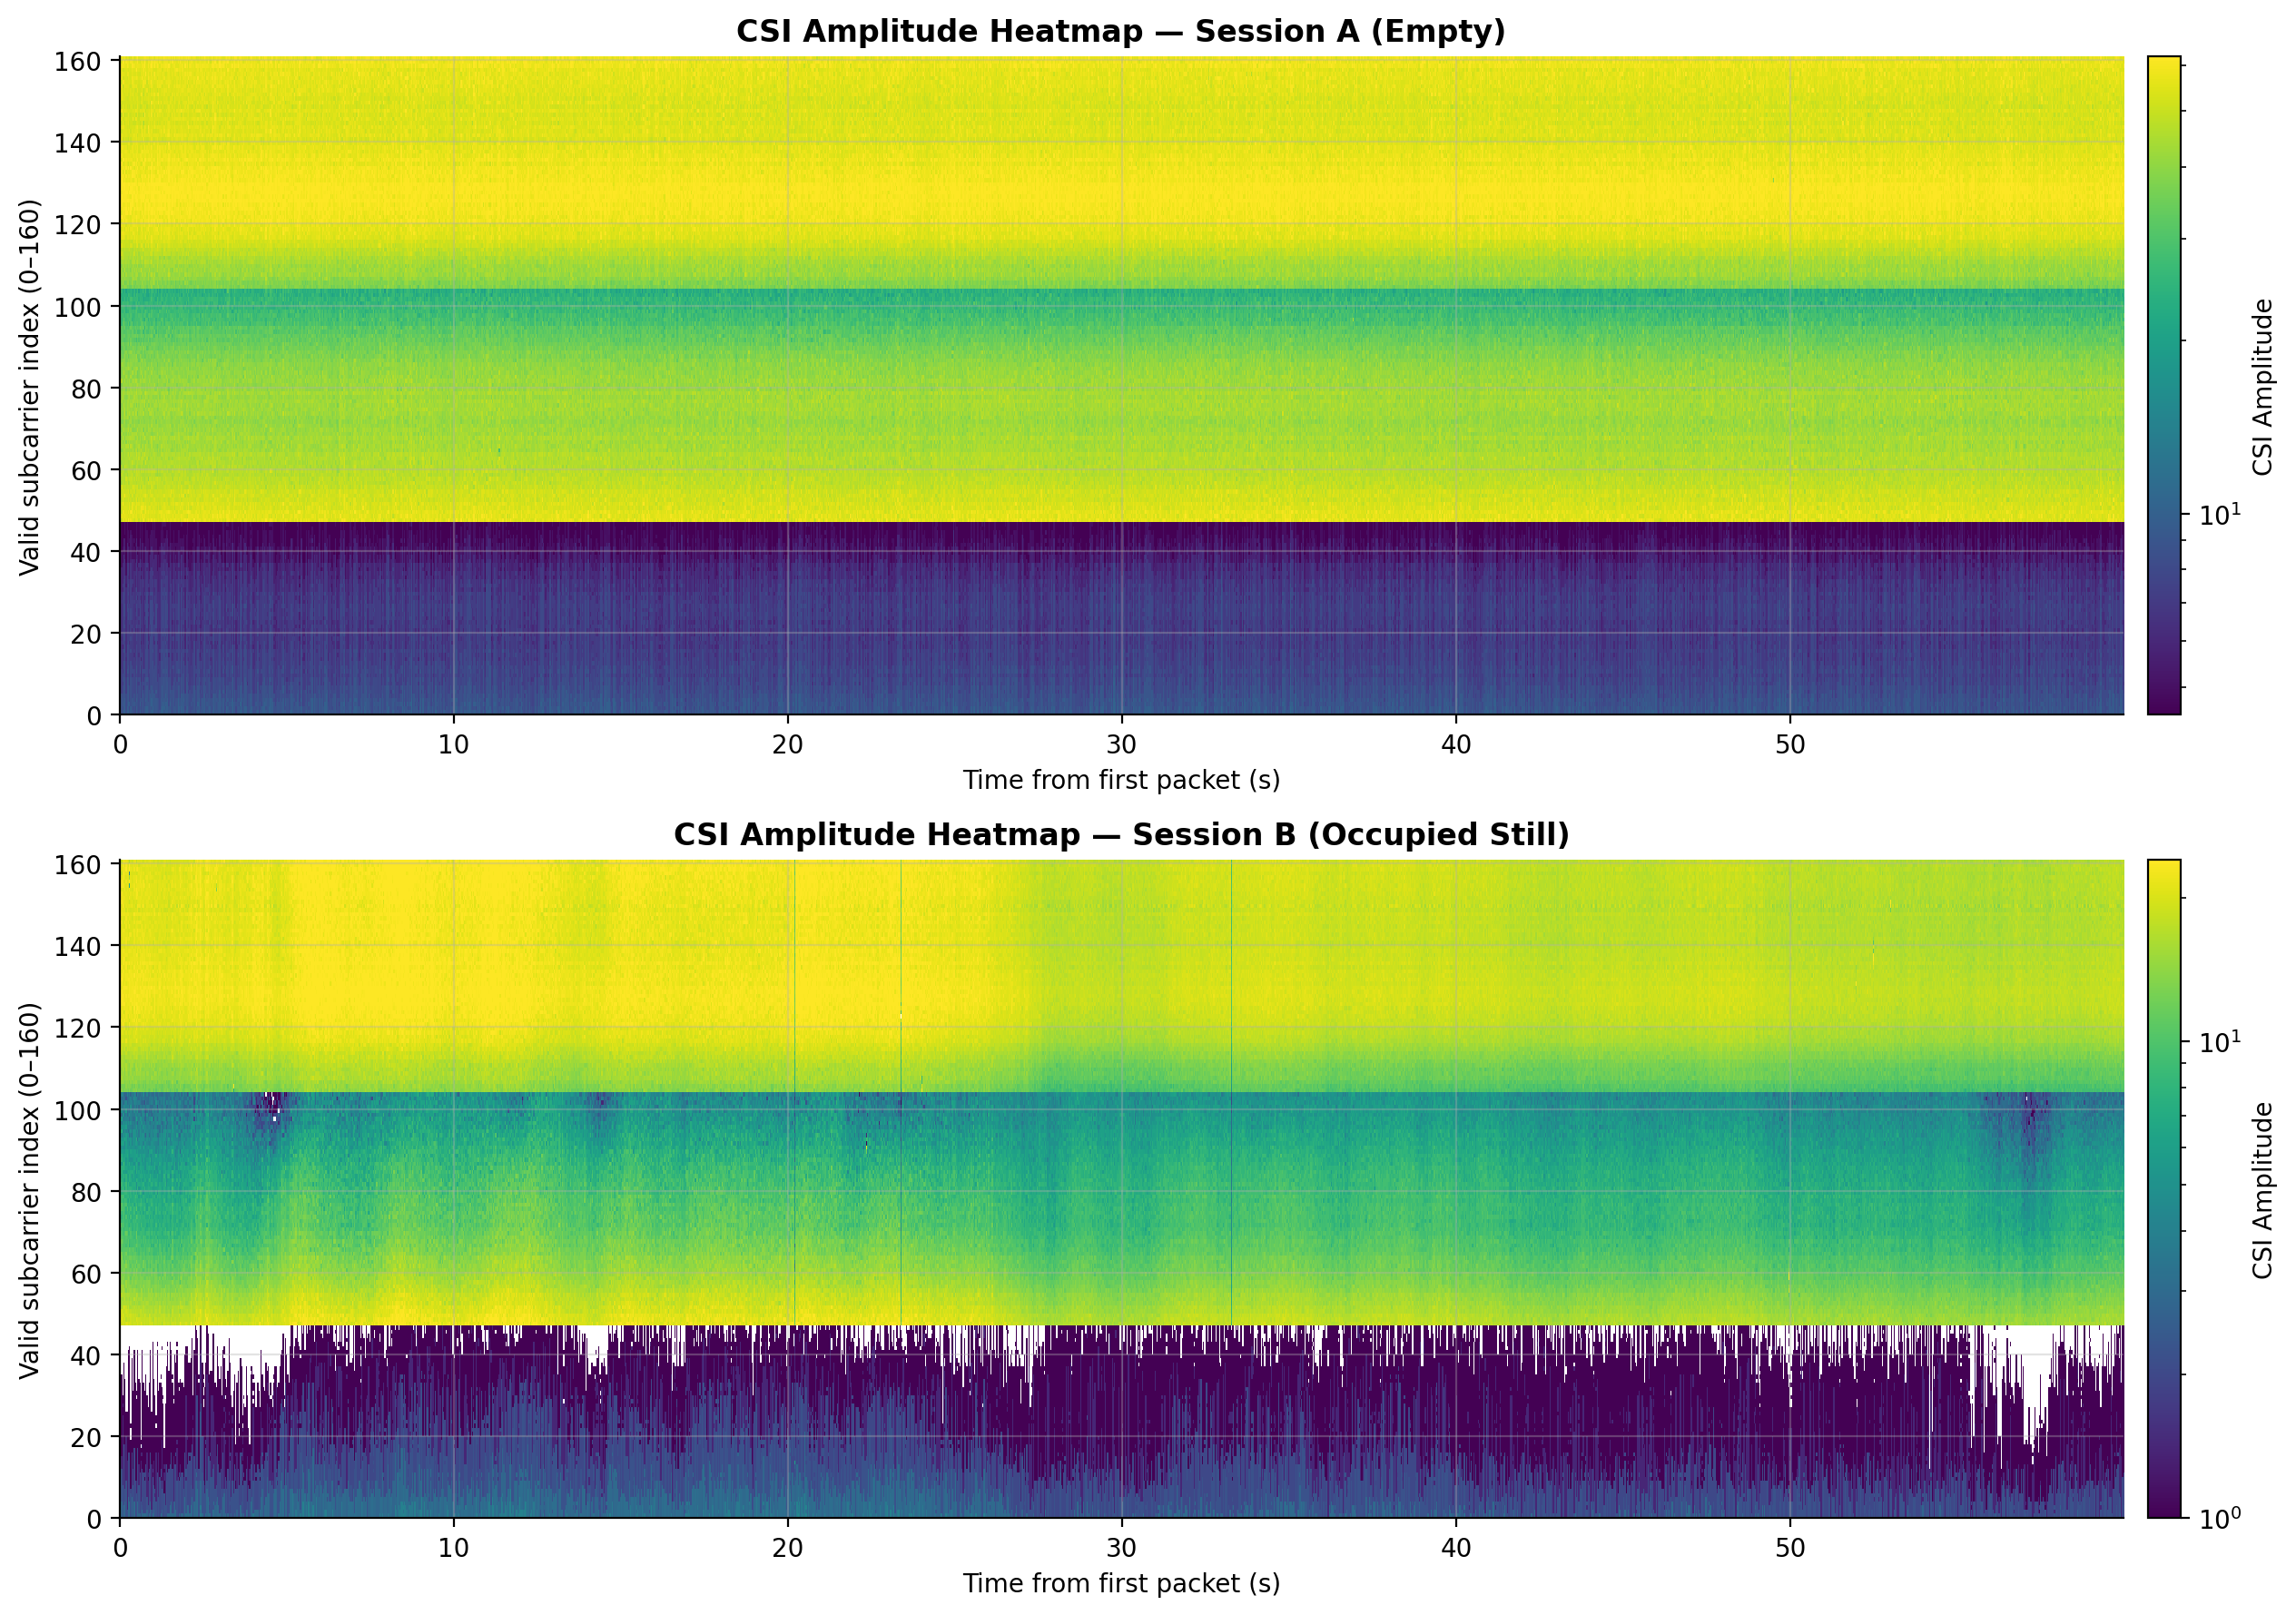

Saved: ./outputs/03_csi_amplitude_heatmap.png


In [8]:
fig, axes = plt.subplots(
    len(sessions), 1,
    figsize=(14, 4.5 * len(sessions)),
    squeeze=False
)

for ax, (key, s) in zip(axes[:, 0], sessions.items()):
    amp_v = s["csi_amp"][:, valid_shared].T   # (Ns_valid, T)
    t     = s["time_s"]

    vmin = max(np.percentile(amp_v[amp_v > 0], 2), 0.1)
    vmax = np.percentile(amp_v, 98)

    im = ax.imshow(
        amp_v,
        aspect="auto",
        extent=[t[0], t[-1], 0, n_valid_shared],
        origin="lower",
        cmap="viridis",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        interpolation="nearest",
    )
    plt.colorbar(im, ax=ax, label="CSI Amplitude", pad=0.01)

    # Condition window shading
    if s["t1"] and s["t2"]:
        t1_s = (s["t1"] - s["t0_abs"]).total_seconds()
        t2_s = (s["t2"] - s["t0_abs"]).total_seconds()
        ax.axvspan(t1_s, t2_s, color="white", alpha=0.12)
        ax.axvline(t1_s, color="white", lw=1.2, ls="--", alpha=0.8, label="t1 / t2")
        ax.axvline(t2_s, color="white", lw=1.2, ls="--", alpha=0.8)
        ax.legend(loc="upper right", fontsize=8)

    ax.set_title(f"CSI Amplitude Heatmap - Session {key} ({s['label'].replace('_',' ').title()})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Time from first packet (s)")
    ax.set_ylabel(f"Valid subcarrier index (0–{n_valid_shared-1})")

plt.tight_layout()
path_out = os.path.join(OUTPUT_DIR, "03_csi_amplitude_heatmap.png")
plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {path_out}")


### 6.4 Mean Amplitude Profile per Subcarrier

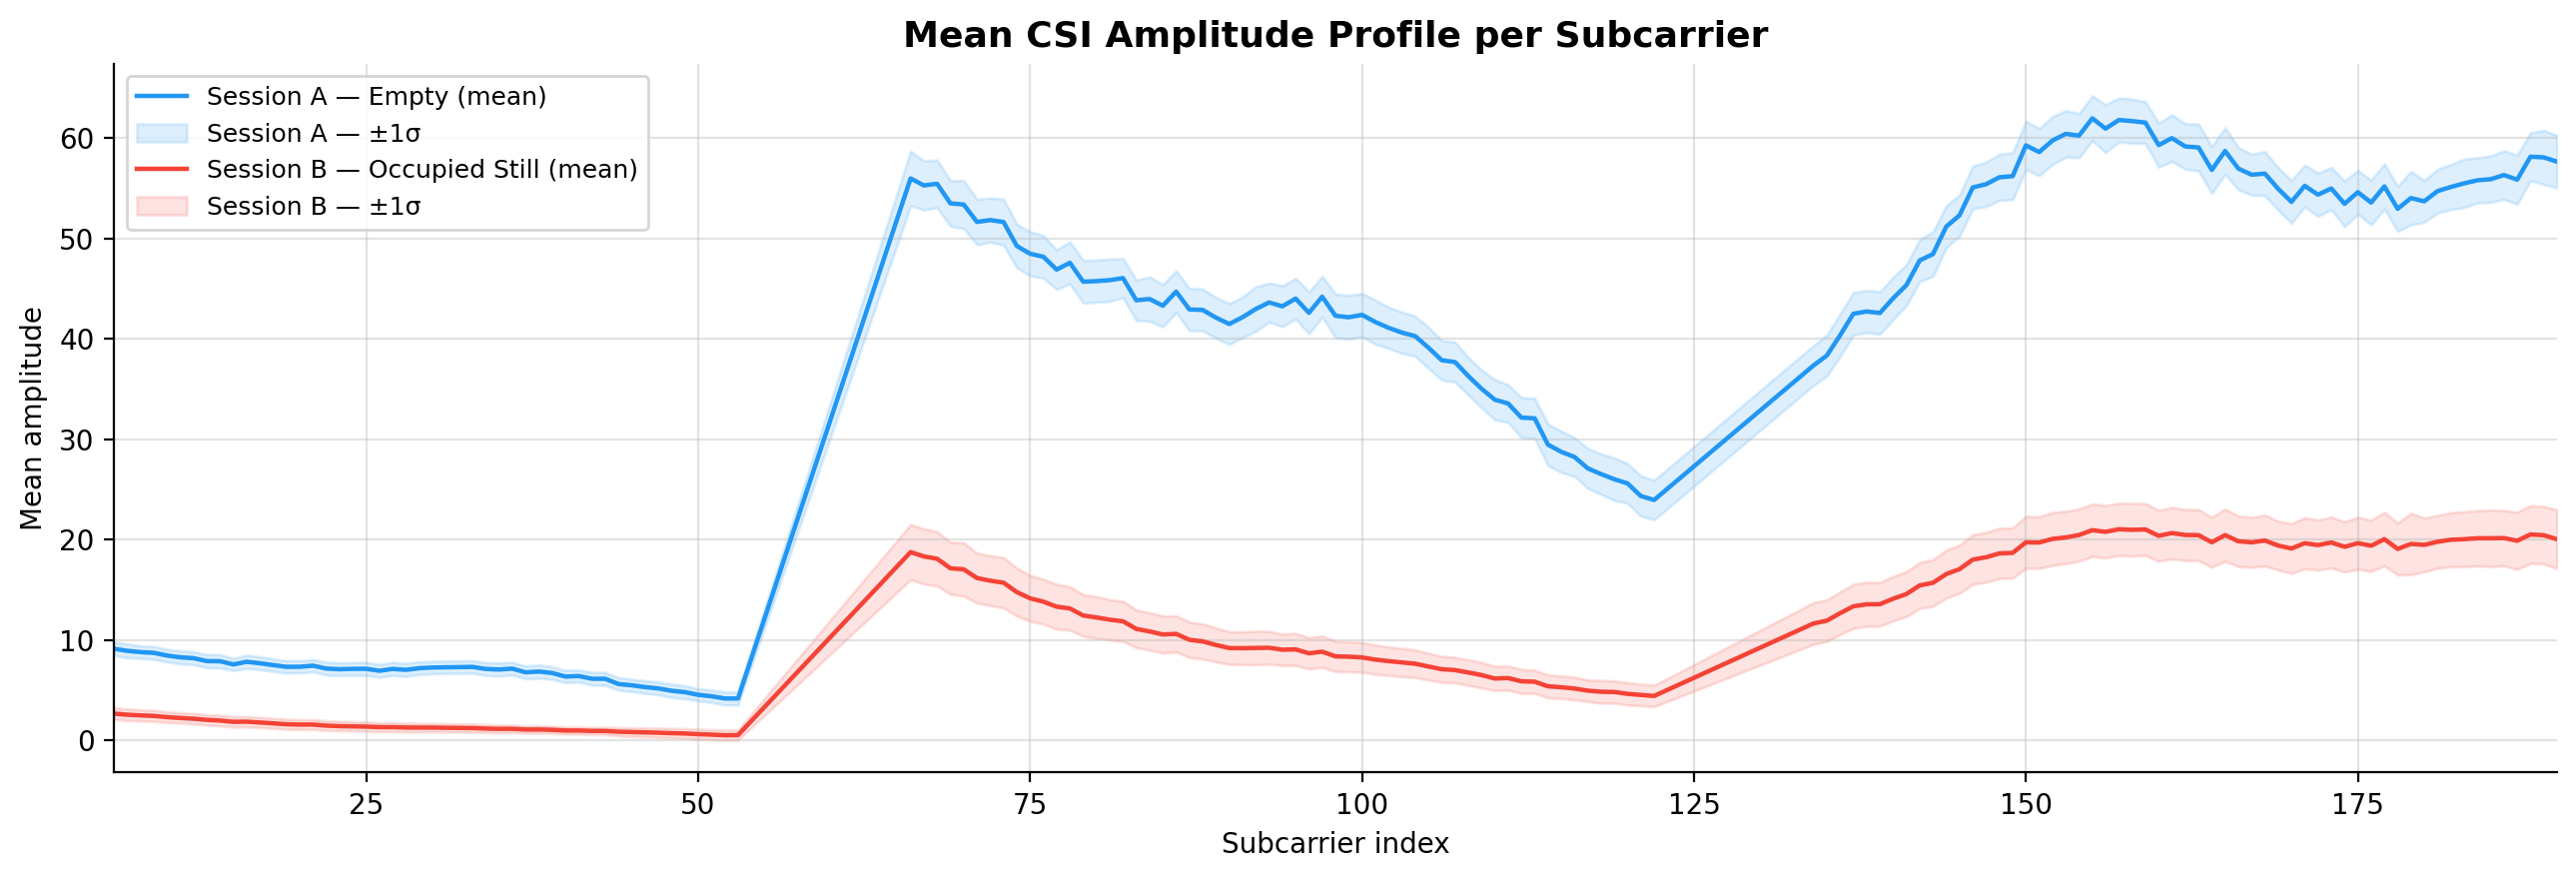

Saved: ./outputs/04_subcarrier_mean_profile.png


In [9]:
fig, ax = plt.subplots(figsize=(13, 4.5))

for key, s in sessions.items():
    amp_v    = s["csi_amp"][:, valid_shared]
    mean_amp = amp_v.mean(axis=0)
    std_amp  = amp_v.std(axis=0)
    color    = get_color(s["label"])
    lbl      = s["label"].replace("_", " ").title()

    ax.plot(sub_indices, mean_amp, label=f"Session {key} - {lbl} (mean)",
            color=color, lw=1.6)
    ax.fill_between(sub_indices,
                    mean_amp - std_amp,
                    mean_amp + std_amp,
                    color=color, alpha=0.15, label=f"Session {key} - ±1σ")

ax.set_title("Mean CSI Amplitude Profile per Subcarrier", fontsize=13, fontweight="bold")
ax.set_xlabel("Subcarrier index")
ax.set_ylabel("Mean amplitude")
ax.legend(fontsize=9)
ax.set_xlim(sub_indices[0], sub_indices[-1])

plt.tight_layout()
path_out = os.path.join(OUTPUT_DIR, "04_subcarrier_mean_profile.png")
plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {path_out}")


### 6.5 Per-Subcarrier Variance & Discriminability

> Subcarriers with **high variance in the Occupied session** and **low variance in the Empty session**  
> are the best candidates for binary classification features.


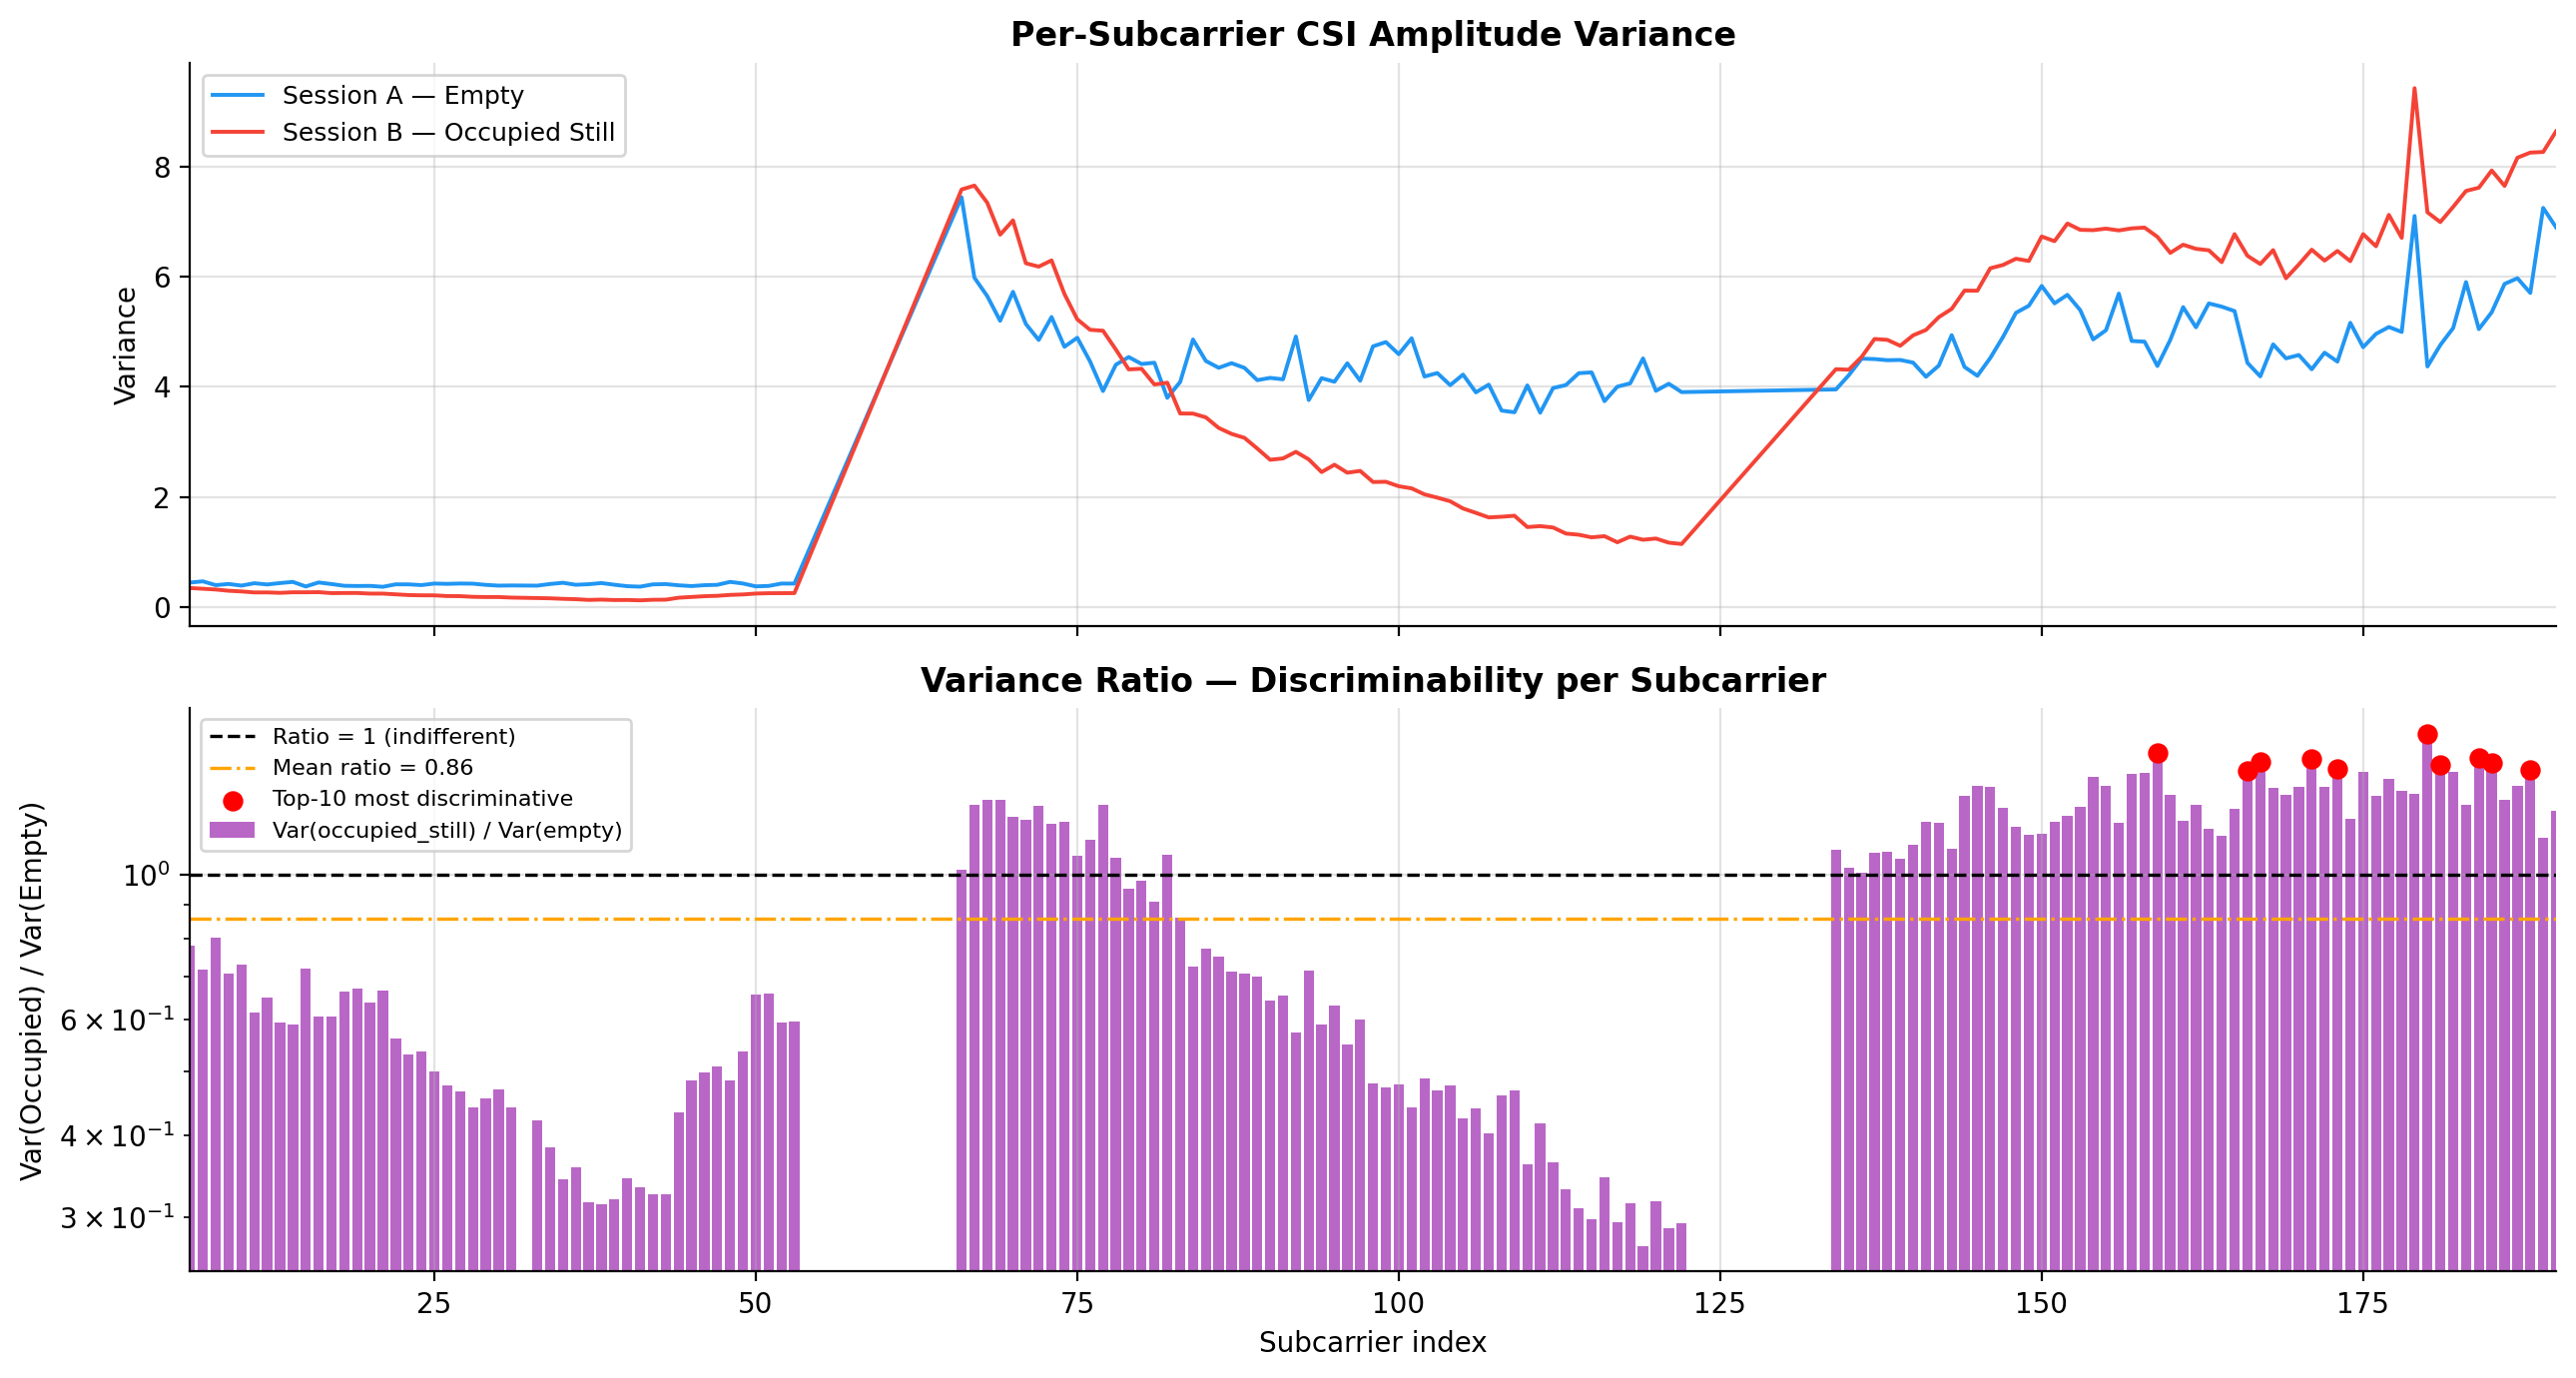

Saved: ./outputs/05_subcarrier_variance_discriminability.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Variance per subcarrier
ax_var = axes[0]
for key, s in sessions.items():
    amp_v  = s["csi_amp"][:, valid_shared]
    color  = get_color(s["label"])
    lbl    = s["label"].replace("_", " ").title()
    ax_var.plot(sub_indices, amp_v.var(axis=0),
                label=f"Session {key} - {lbl}", color=color, lw=1.4)

ax_var.set_title("Per-Subcarrier CSI Amplitude Variance", fontsize=12, fontweight="bold")
ax_var.set_ylabel("Variance")
ax_var.legend(fontsize=9)

# Variance ratio (discriminability)
ax_ratio = axes[1]
if len(sess_list) == 2:
    s_e = next((s for s in sess_list if "empty" in s["label"]), sess_list[0])
    s_o = next((s for s in sess_list if s is not s_e), sess_list[1])

    var_e = s_e["csi_amp"][:, valid_shared].var(axis=0)
    var_o = s_o["csi_amp"][:, valid_shared].var(axis=0)
    ratio = var_o / (var_e + 1e-9)

    ax_ratio.bar(sub_indices, ratio, color="#9C27B0", alpha=0.7, width=0.8,
                 label=f"Var({s_o['label']}) / Var({s_e['label']})")
    ax_ratio.axhline(1.0,        color="black",  lw=1.2, ls="--", label="Ratio = 1 (indifferent)")
    ax_ratio.axhline(ratio.mean(), color="orange", lw=1.2, ls="-.",
                     label=f"Mean ratio = {ratio.mean():.2f}")

    top10_local  = np.argsort(ratio)[-10:][::-1]
    top10_global = sub_indices[top10_local]
    ax_ratio.scatter(top10_global, ratio[top10_local],
                     color="red", zorder=5, s=40, label="Top-10 most discriminative")

    ax_ratio.set_title("Variance Ratio - Discriminability per Subcarrier",
                       fontsize=12, fontweight="bold")
    ax_ratio.set_ylabel("Var(Occupied) / Var(Empty)")
    ax_ratio.set_yscale("log")
    ax_ratio.legend(fontsize=8)
else:
    ax_ratio.text(0.5, 0.5, "Two sessions required to compute variance ratio.",
                  ha="center", va="center", transform=ax_ratio.transAxes, fontsize=11)

ax_ratio.set_xlabel("Subcarrier index")
ax_ratio.set_xlim(sub_indices[0], sub_indices[-1])

plt.tight_layout()
path_out = os.path.join(OUTPUT_DIR, "05_subcarrier_variance_discriminability.png")
plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {path_out}")


### 6.6 Time Series - Top-6 Most Discriminative Subcarriers

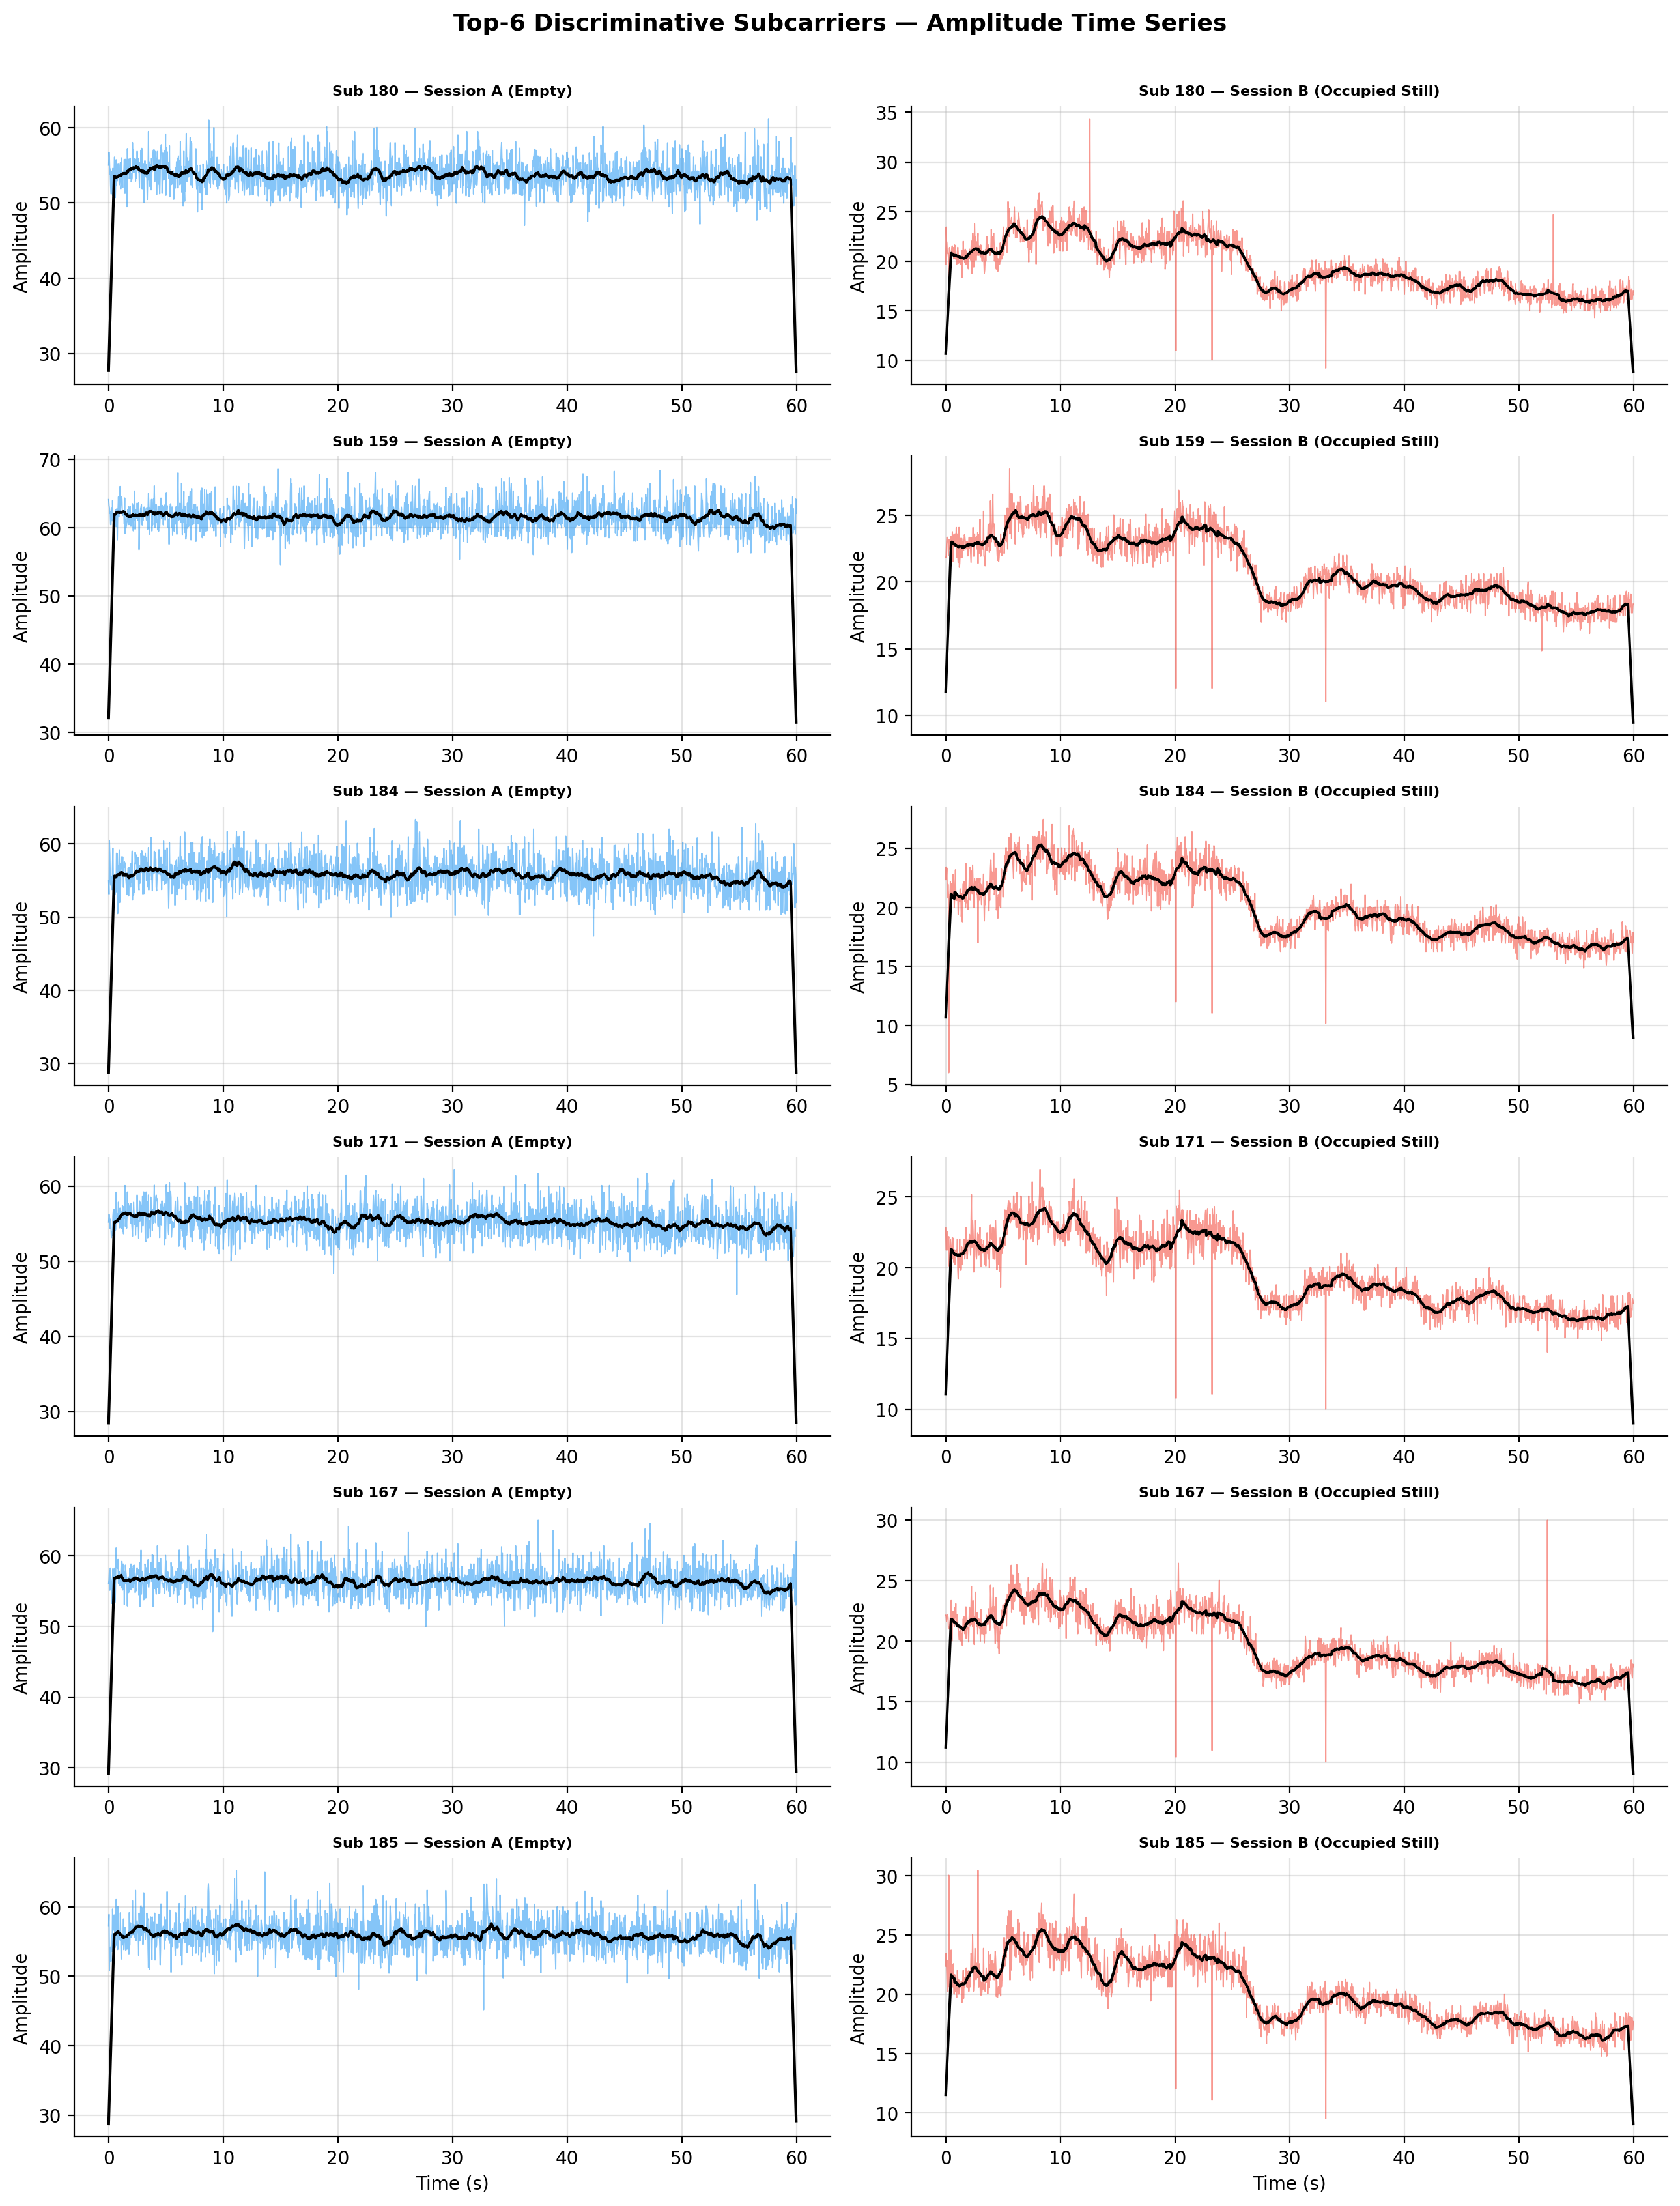

Saved: ./outputs/06_top_subcarriers_timeseries.png


In [11]:
N_TOP = 6

if len(sess_list) == 2:
    s_e      = next((s for s in sess_list if "empty"    in s["label"]), sess_list[0])
    s_o      = next((s for s in sess_list if s is not s_e),             sess_list[1])
    var_e    = s_e["csi_amp"][:, valid_shared].var(axis=0)
    var_o    = s_o["csi_amp"][:, valid_shared].var(axis=0)
    ratio    = var_o / (var_e + 1e-9)
    top_loc  = np.argsort(ratio)[-N_TOP:][::-1]
else:
    amp_ref  = sess_list[0]["csi_amp"][:, valid_shared]
    top_loc  = np.argsort(amp_ref.var(axis=0))[-N_TOP:][::-1]

top_glob = sub_indices[top_loc]

fig, axes = plt.subplots(N_TOP, len(sessions),
                          figsize=(13, 2.8 * N_TOP),
                          sharey=False, squeeze=False)

for col, (key, s) in enumerate(sessions.items()):
    amp_v = s["csi_amp"][:, valid_shared]
    t     = s["time_s"]
    color = get_color(s["label"])

    for row, (loc_i, glob_i) in enumerate(zip(top_loc, top_glob)):
        ax     = axes[row][col]
        series = amp_v[:, loc_i]

        ax.plot(t, series, color=color, lw=0.7, alpha=0.55)
        win    = max(1, int(s["eff_rate_hz"]))
        smooth = np.convolve(series, np.ones(win)/win, mode="same")
        ax.plot(t, smooth, color="black", lw=1.5)

        # Condition window
        if s["t1"] and s["t2"]:
            t1_s = (s["t1"] - s["t0_abs"]).total_seconds()
            t2_s = (s["t2"] - s["t0_abs"]).total_seconds()
            ax.axvspan(t1_s, t2_s, color=color, alpha=0.12)

        ax.set_title(f"Sub {glob_i} - Session {key} ({s['label'].replace('_',' ').title()})",
                     fontsize=8, fontweight="bold")
        ax.set_ylabel("Amplitude")
        if row == N_TOP - 1:
            ax.set_xlabel("Time (s)")

plt.suptitle("Top-6 Discriminative Subcarriers - Amplitude Time Series",
             fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
path_out = os.path.join(OUTPUT_DIR, "06_top_subcarriers_timeseries.png")
plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {path_out}")


### 6.7 Amplitude Distribution per Subcarrier (Boxplot)

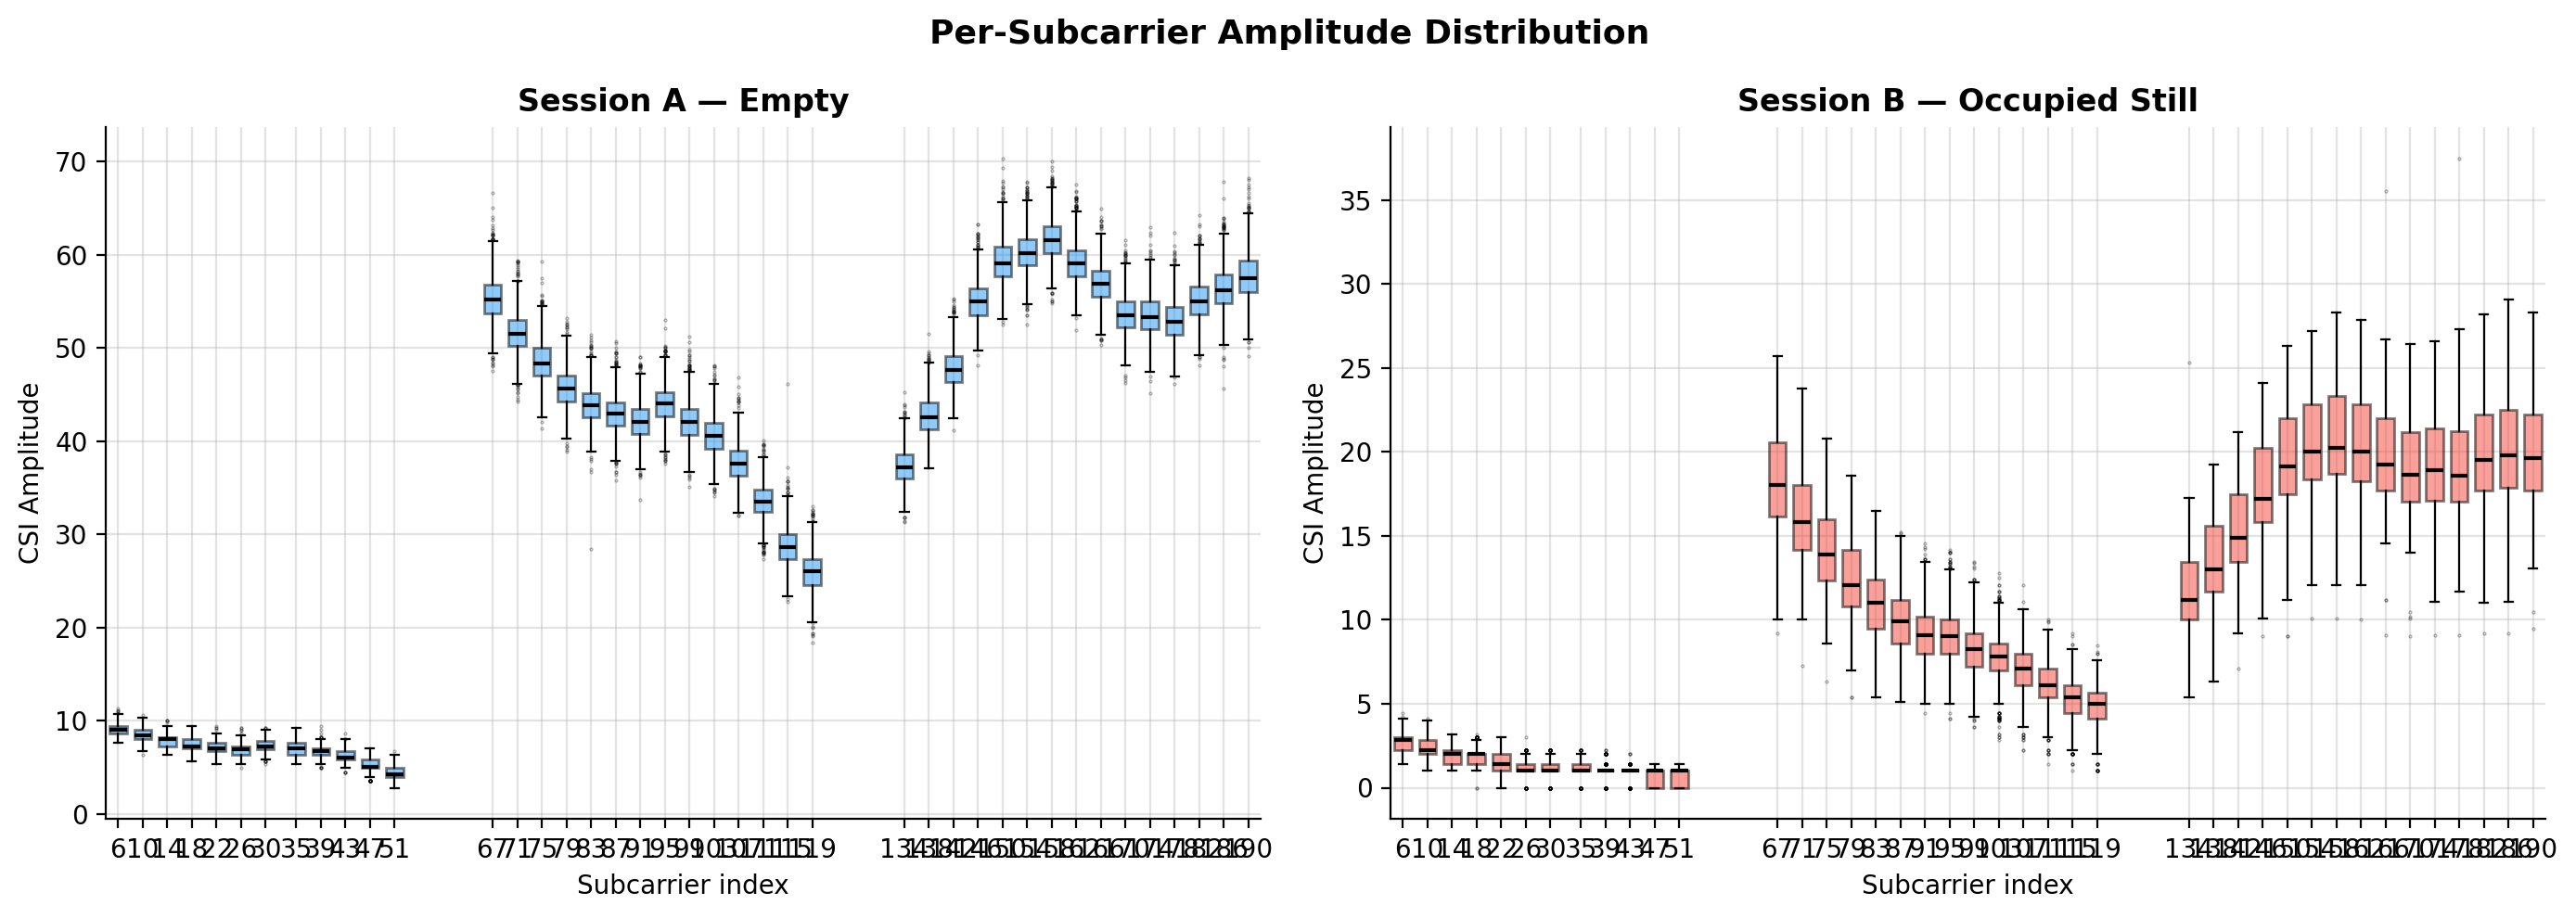

Saved: ./outputs/07_amplitude_boxplot.png


In [12]:
if len(sessions) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (key, s) in zip(axes, sessions.items()):
        amp_v = s["csi_amp"][:, valid_shared]
        color = get_color(s["label"])
        step  = max(1, n_valid_shared // 40)
        sample = np.arange(0, n_valid_shared, step)

        ax.boxplot(
            [amp_v[:, i] for i in sample],
            positions=sub_indices[sample],
            widths=step * 0.7,
            patch_artist=True,
            boxprops=dict(facecolor=color, alpha=0.5),
            medianprops=dict(color="black", lw=1.5),
            flierprops=dict(marker=".", markersize=1, alpha=0.3),
            whiskerprops=dict(lw=0.8),
            capprops=dict(lw=0.8),
        )
        ax.set_title(f"Session {key} - {s['label'].replace('_',' ').title()}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Subcarrier index")
        ax.set_ylabel("CSI Amplitude")
        ax.set_xlim(sub_indices[0] - 2, sub_indices[-1] + 2)

    plt.suptitle("Per-Subcarrier Amplitude Distribution", fontsize=13, fontweight="bold")
    plt.tight_layout()
    path_out = os.path.join(OUTPUT_DIR, "07_amplitude_boxplot.png")
    plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path_out}")


### 6.8 Global Amplitude Histogram: Empty vs. Occupied

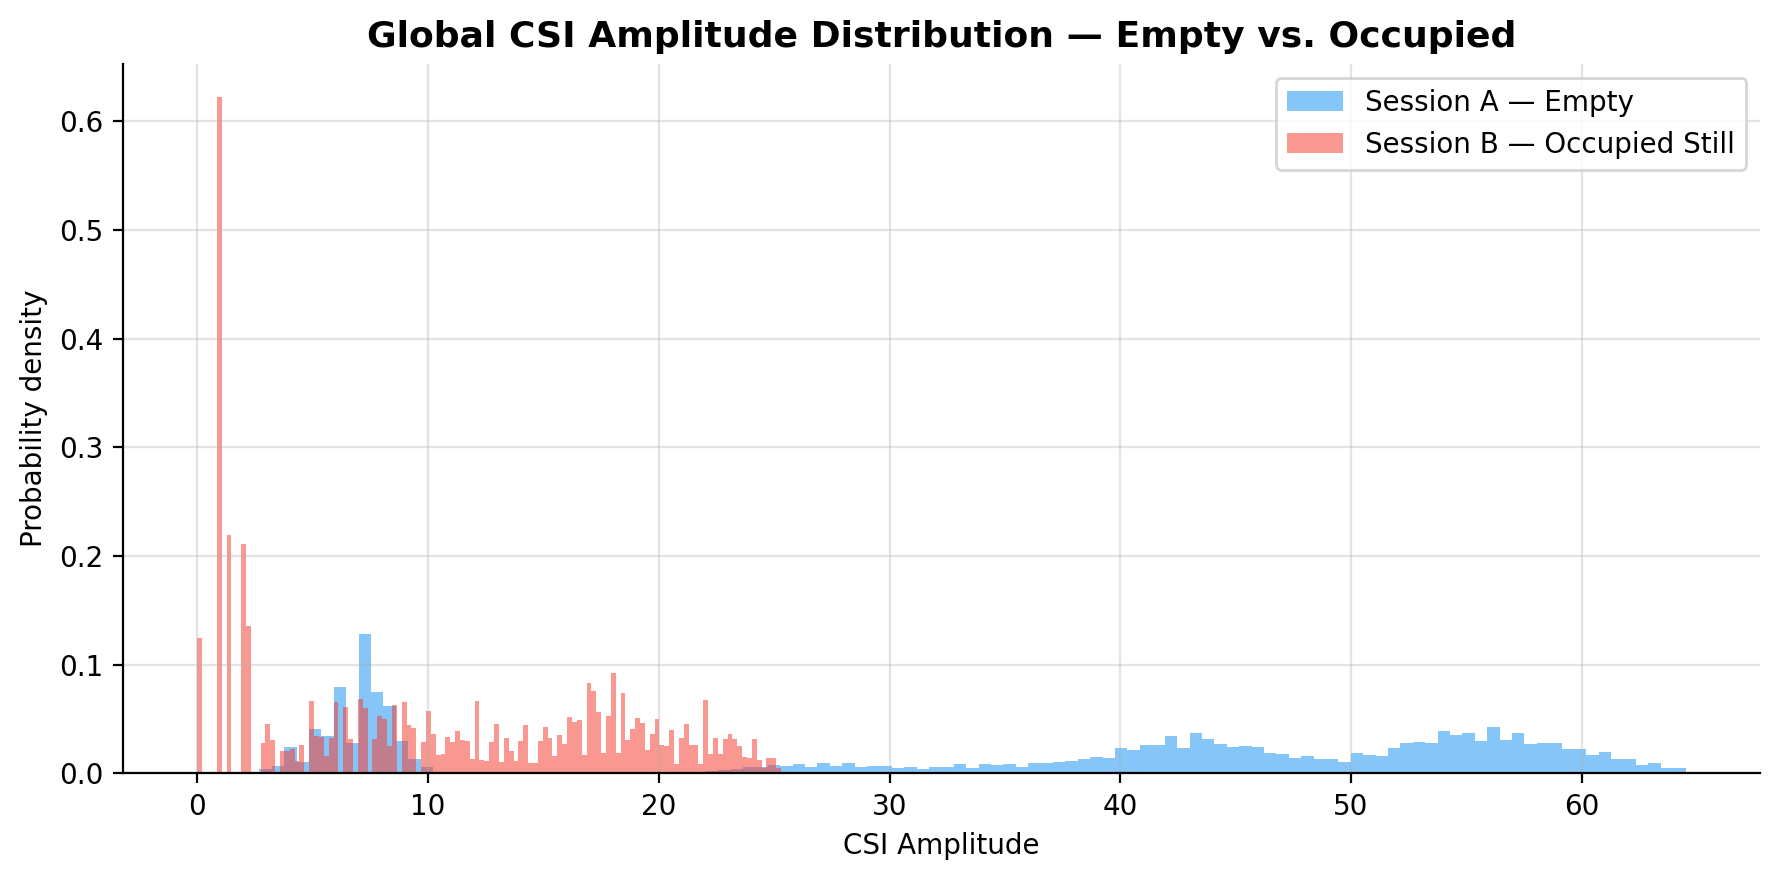

Saved: ./outputs/08_global_amplitude_histogram.png


In [13]:
if len(sessions) == 2:
    fig, ax = plt.subplots(figsize=(9, 4.5))

    for key, s in sessions.items():
        amp_flat = s["csi_amp"][:, valid_shared].ravel()
        color    = get_color(s["label"])
        lbl      = s["label"].replace("_", " ").title()
        ax.hist(amp_flat, bins=120, color=color, alpha=0.55, density=True,
                label=f"Session {key} - {lbl}",
                range=(0, np.percentile(amp_flat, 99.5)))

    ax.set_title("Global CSI Amplitude Distribution - Empty vs. Occupied",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("CSI Amplitude")
    ax.set_ylabel("Probability density")
    ax.legend(fontsize=10)

    plt.tight_layout()
    path_out = os.path.join(OUTPUT_DIR, "08_global_amplitude_histogram.png")
    plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path_out}")


### 6.9 Unwrapped Phase - Top-3 Discriminative Subcarriers

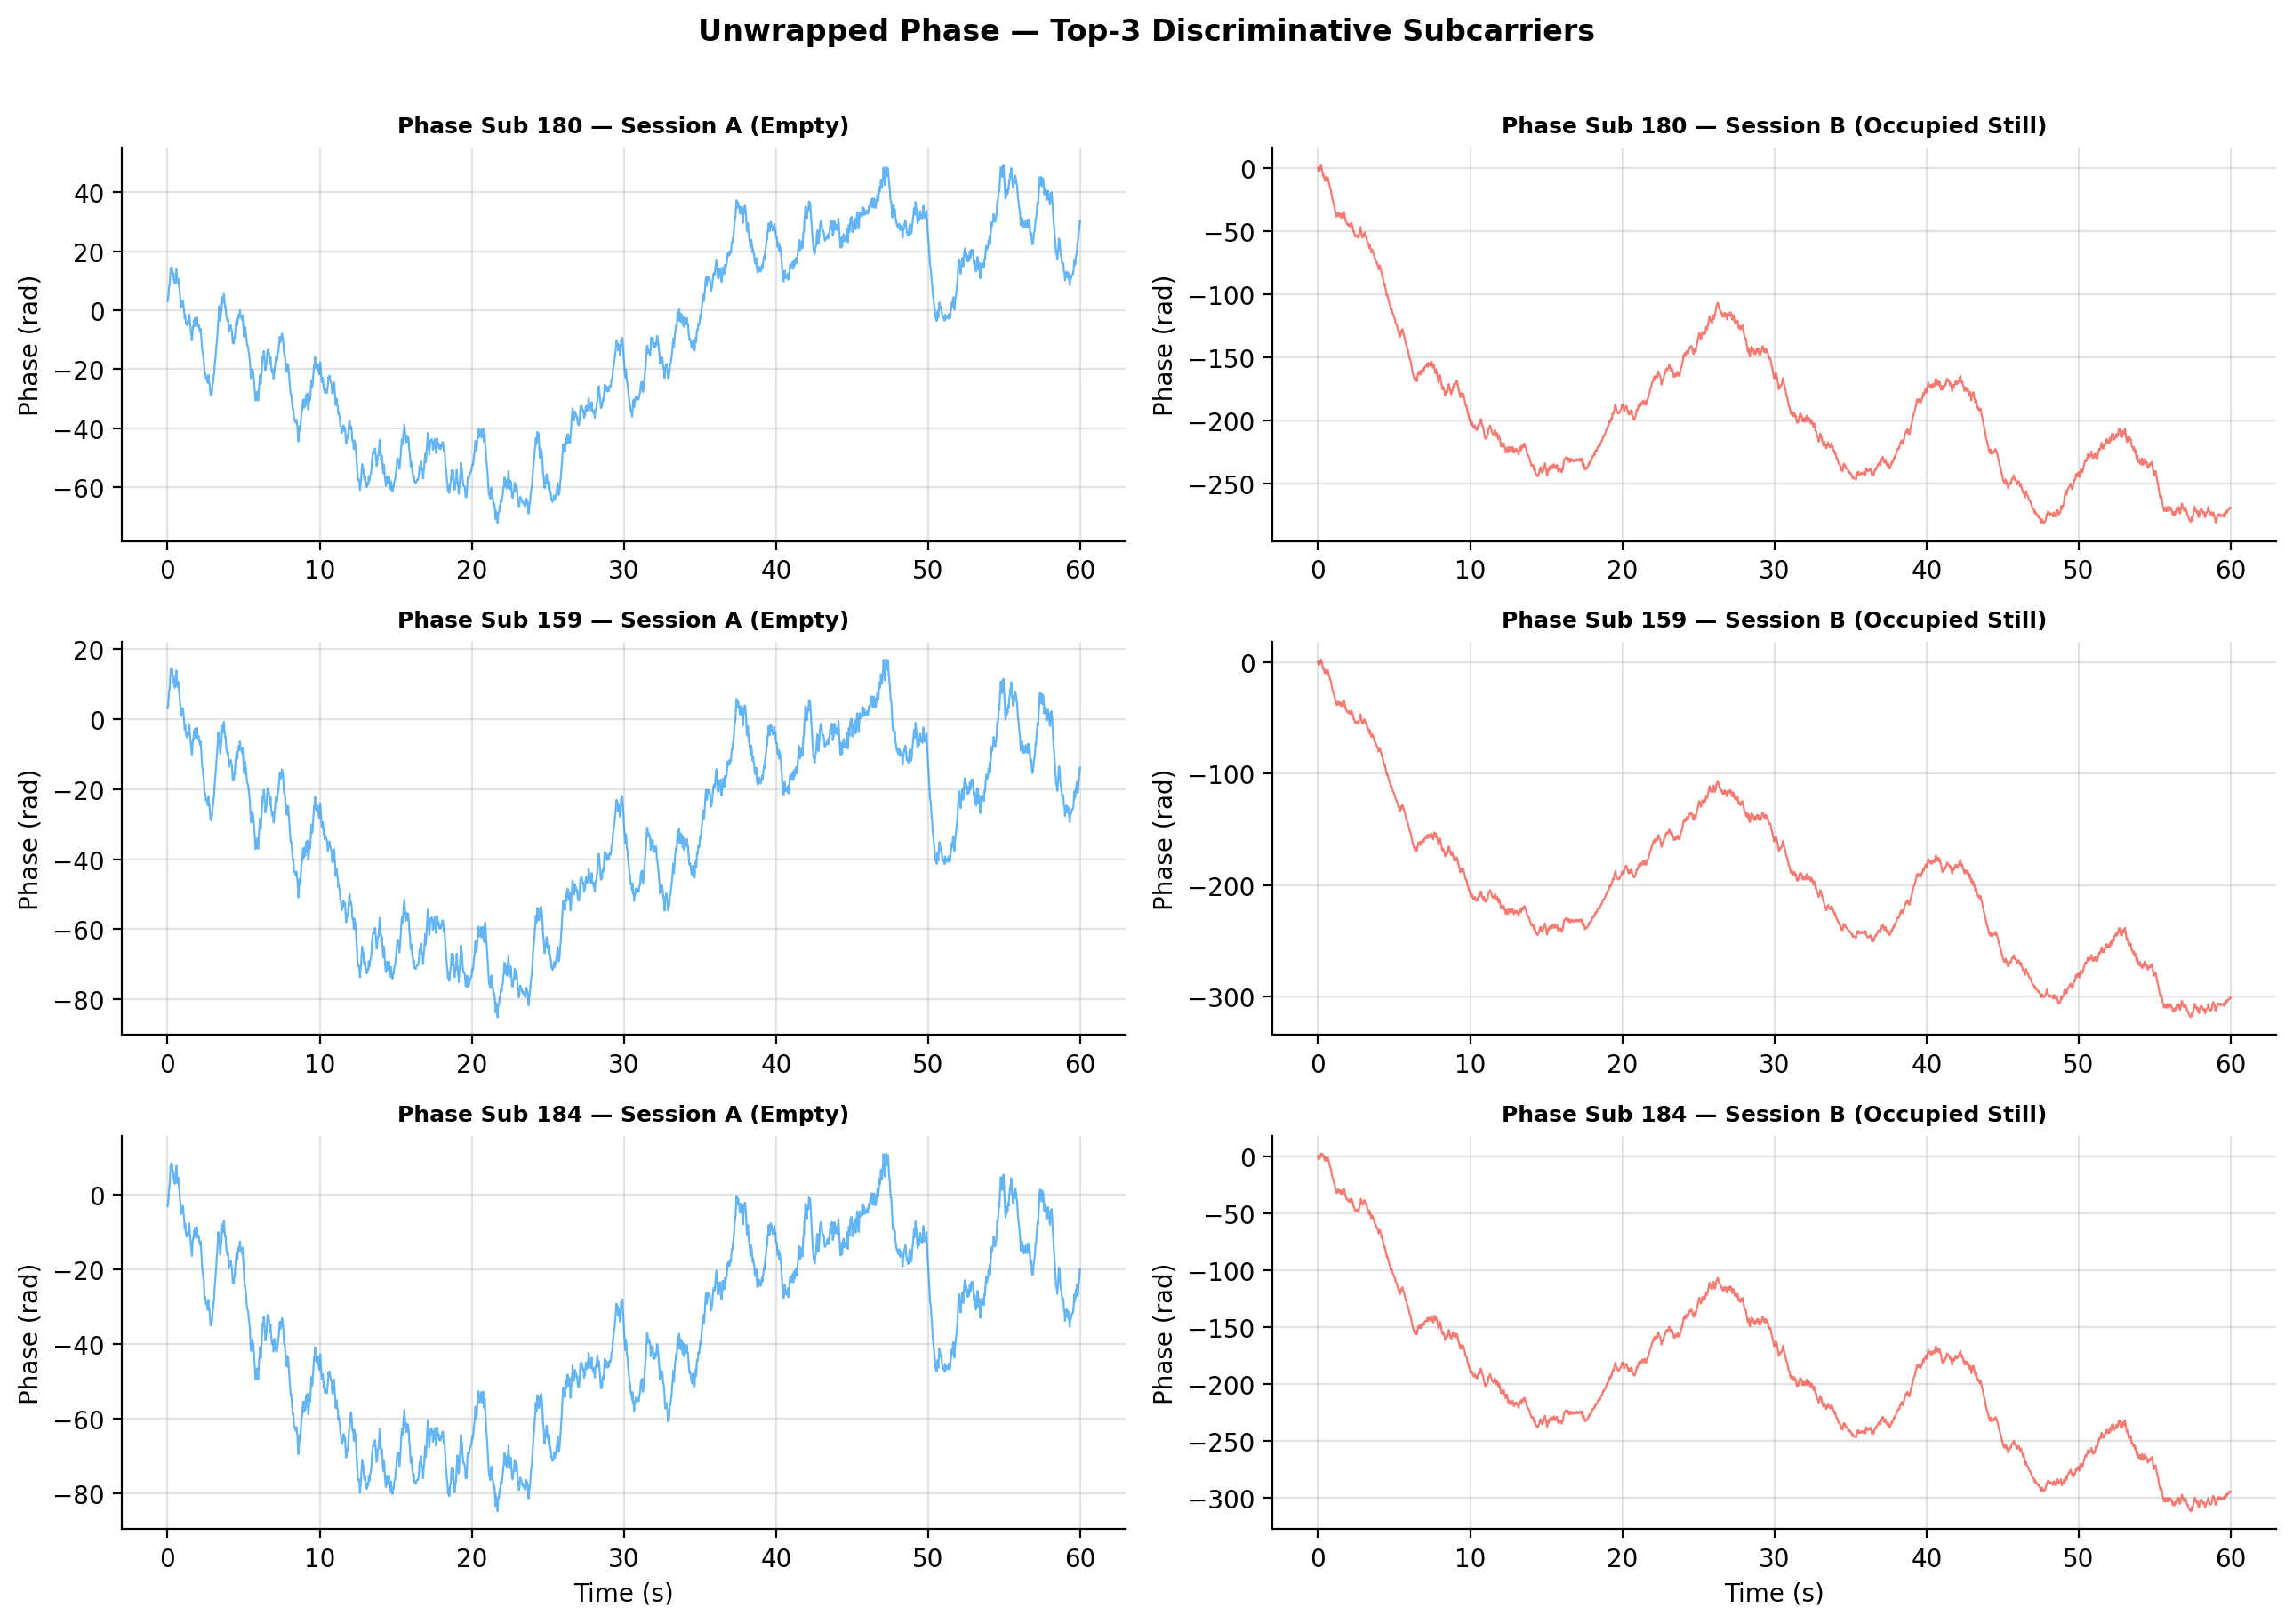

Saved: ./outputs/09_phase_timeseries.png


In [14]:
fig, axes = plt.subplots(
    min(3, N_TOP), len(sessions),
    figsize=(13, 3.0 * min(3, N_TOP)),
    sharey=False, squeeze=False
)

for col, (key, s) in enumerate(sessions.items()):
    phase_v = s["csi_phase"][:, valid_shared]
    t       = s["time_s"]
    color   = get_color(s["label"])

    for row, (loc_i, glob_i) in enumerate(zip(top_loc[:3], top_glob[:3])):
        ax    = axes[row][col]
        phase = np.unwrap(phase_v[:, loc_i])
        ax.plot(t, phase, color=color, lw=0.8, alpha=0.7)

        if s["t1"] and s["t2"]:
            t1_s = (s["t1"] - s["t0_abs"]).total_seconds()
            t2_s = (s["t2"] - s["t0_abs"]).total_seconds()
            ax.axvspan(t1_s, t2_s, color=color, alpha=0.12)

        ax.set_title(f"Phase Sub {glob_i} - Session {key} ({s['label'].replace('_',' ').title()})",
                     fontsize=9, fontweight="bold")
        ax.set_ylabel("Phase (rad)")
        if row == 2:
            ax.set_xlabel("Time (s)")

plt.suptitle("Unwrapped Phase - Top-3 Discriminative Subcarriers",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
path_out = os.path.join(OUTPUT_DIR, "09_phase_timeseries.png")
plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {path_out}")


### 6.10 MAD Activity Indicator

> The Mean Absolute Deviation (MAD) of CSI amplitude computed over sliding windows acts as a  
> **channel-activity detector**: high MAD indicates physical perturbation (human presence / motion).


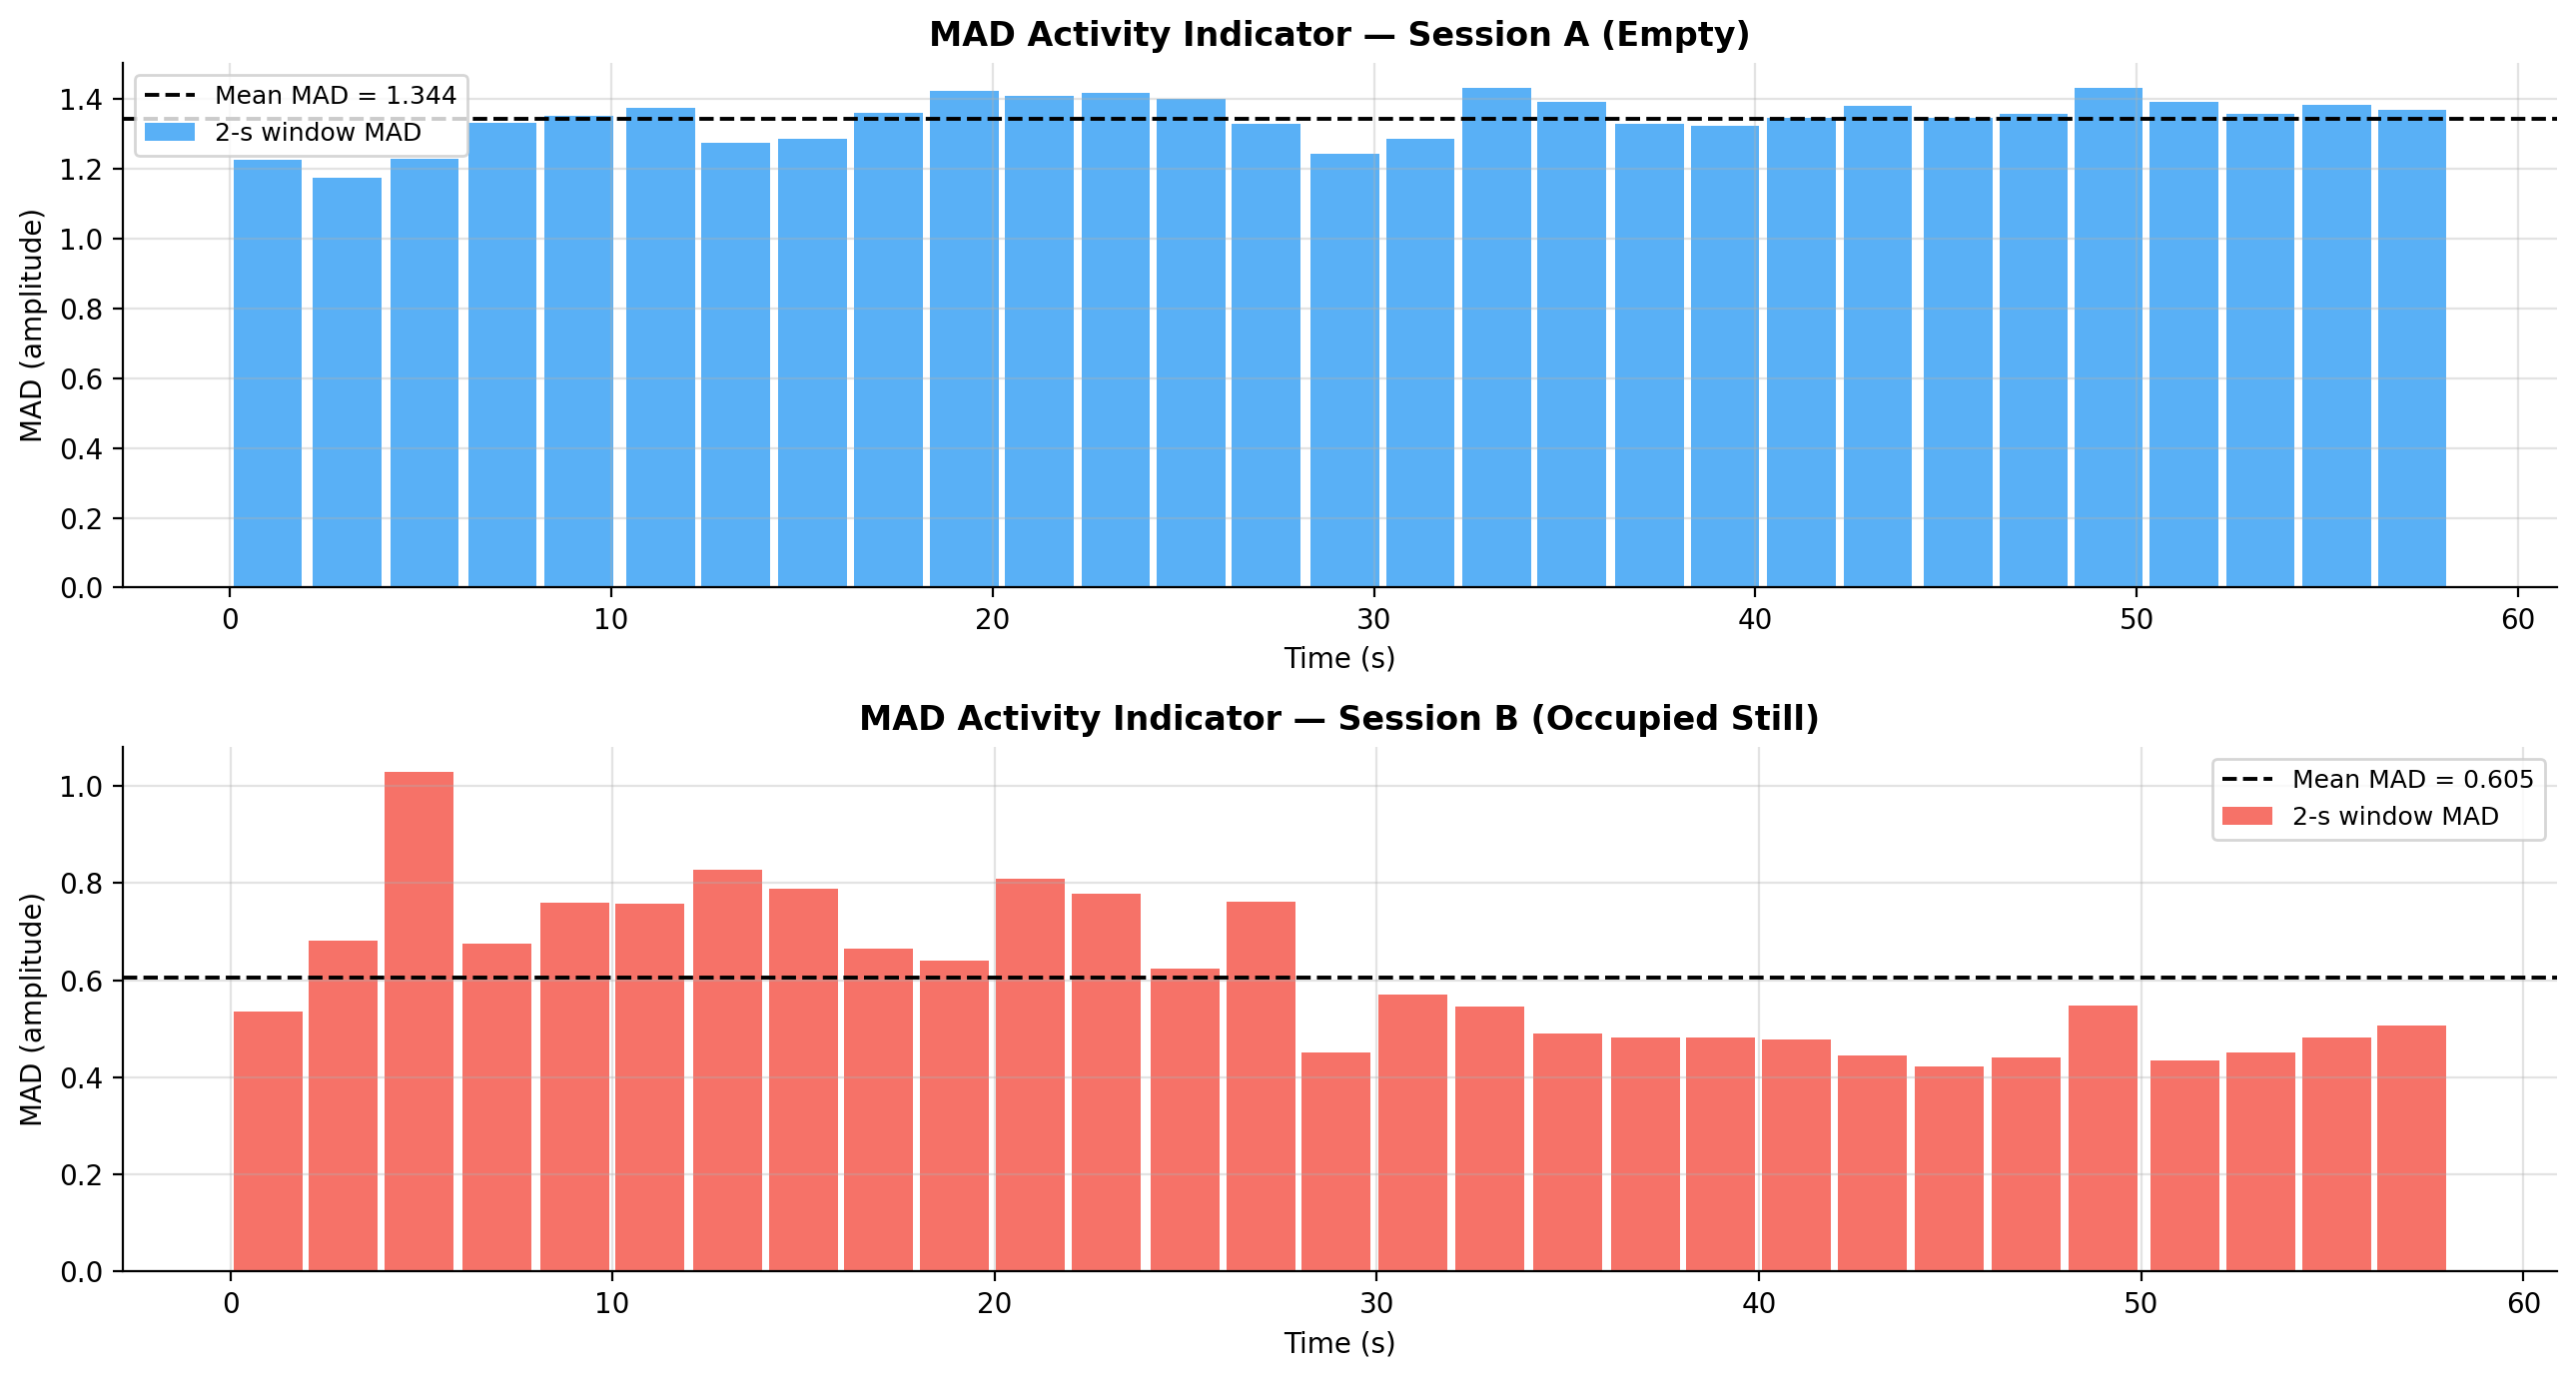

Saved: ./outputs/10_mad_activity_indicator.png


In [15]:
WINDOW_S = 2.0

fig, axes = plt.subplots(
    len(sessions), 1,
    figsize=(13, 3.5 * len(sessions)),
    sharex=False, squeeze=False
)

for ax, (key, s) in zip(axes[:, 0], sessions.items()):
    amp_v = s["csi_amp"][:, valid_shared]
    t     = s["time_s"]
    rate  = s["eff_rate_hz"]
    color = get_color(s["label"])

    win_n   = max(2, int(WINDOW_S * rate))
    n_win   = len(t) // win_n
    t_win   = np.array([t[i * win_n + win_n // 2] for i in range(n_win)])
    mad_win = np.array([
        np.mean(np.abs(amp_v[i*win_n:(i+1)*win_n] -
                       amp_v[i*win_n:(i+1)*win_n].mean(axis=0)))
        for i in range(n_win)
    ])

    ax.bar(t_win, mad_win, width=WINDOW_S * 0.9, color=color, alpha=0.75,
           label=f"{WINDOW_S:.0f}-s window MAD")
    ax.axhline(mad_win.mean(), color="black", lw=1.4, ls="--",
               label=f"Mean MAD = {mad_win.mean():.3f}")

    if s["t1"] and s["t2"]:
        t1_s = (s["t1"] - s["t0_abs"]).total_seconds()
        t2_s = (s["t2"] - s["t0_abs"]).total_seconds()
        ax.axvspan(t1_s, t2_s, color=color, alpha=0.10)
        ax.axvline(t1_s, color="green",  lw=1.2, ls="--")
        ax.axvline(t2_s, color="crimson", lw=1.2, ls="--")

    ax.set_title(f"MAD Activity Indicator - Session {key} ({s['label'].replace('_',' ').title()})",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("MAD (amplitude)")
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=9)

plt.tight_layout()
path_out = os.path.join(OUTPUT_DIR, "10_mad_activity_indicator.png")
plt.savefig(path_out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {path_out}")


## 7 - Viability Verdict

In [16]:
print("=" * 65)
print("  PILOT DATASET - VIABILITY ASSESSMENT")
print("=" * 65)

all_passed = True

for s in sess_list:
    r      = quality_report(s)
    nom    = r["nominal_hz"]
    issues = []

    if r["loss_pct"] >= 5:
        issues.append(f"High packet loss: {r['loss_pct']:.1f} % (threshold 5 %)")
    if abs(r["rate_eff_hz"] - nom) / nom >= 0.10:
        issues.append(f"Rate deviation: {r['rate_eff_hz']:.1f} Hz vs. {nom:.0f} Hz nominal")
    if r["rssi_std"] >= 5:
        issues.append(f"Unstable RSSI: std = {r['rssi_std']:.2f} dBm")
    if r["n_valid_sub"] < 40:
        issues.append(f"Too few valid subcarriers: {r['n_valid_sub']}")
    if s["meta"] and s["meta"].get("timing", {}).get("status") == "INVALID":
        reason = s["meta"]["timing"].get("invalidation_reason", "unspecified")
        issues.append(f"Session marked INVALID by collector: {reason}")

    print(f"\n[{s['label'].upper()}]")
    if not issues:
        print("  All criteria passed.")
    else:
        all_passed = False
        for msg in issues:
            print(f"  [FAIL] {msg}")

# Separability index (Cohen's d proxy)
if len(sess_list) == 2:
    s_e = next((s for s in sess_list if "empty"    in s["label"]), sess_list[0])
    s_o = next((s for s in sess_list if s is not s_e),             sess_list[1])

    mean_e = s_e["csi_amp"][:, valid_shared].mean(axis=1)
    mean_o = s_o["csi_amp"][:, valid_shared].mean(axis=1)
    cohens_d = abs(mean_e.mean() - mean_o.mean()) / (
               (mean_e.std() + mean_o.std()) / 2 + 1e-9)

    print(f"\n[SEPARABILITY - Empty vs. Occupied]")
    print(f"  Cohen's d proxy: {cohens_d:.3f}")
    if cohens_d > 0.8:
        print("  Large effect size - strong channel separation.")
    elif cohens_d > 0.5:
        print("  Medium effect size - sufficient for classification.")
    else:
        print("  [WARNING] Small effect size - review experimental setup.")
        all_passed = False

print()
print("=" * 65)
if all_passed:
    print("  CONCLUSION: Pilot collection validated.")
    print("  The project may advance to the full dataset phase.")
else:
    print("  CONCLUSION: Issues detected - review flagged items")
    print("  before proceeding to the full dataset collection.")
print("=" * 65)

saved = sorted(Path(OUTPUT_DIR).glob("*.png"))
print(f"\n{len(saved)} figures saved to {os.path.abspath(OUTPUT_DIR)}/")
for p in saved:
    print(f"  {p.name}")


  PILOT DATASET - VIABILITY ASSESSMENT

[EMPTY]
  All criteria passed.

[OCCUPIED_STILL]
  All criteria passed.

[SEPARABILITY - Empty vs. Occupied]
  Cohen's d proxy: 25.427
  Large effect size - strong channel separation.

  CONCLUSION: Pilot collection validated.
  The project may advance to the full dataset phase.

10 figures saved to /home/xavier/code/wifi-csi-presence-detection/first_test/outputs/
  01_recording_timeline.png
  02_packet_interval.png
  03_csi_amplitude_heatmap.png
  04_subcarrier_mean_profile.png
  05_subcarrier_variance_discriminability.png
  06_top_subcarriers_timeseries.png
  07_amplitude_boxplot.png
  08_global_amplitude_histogram.png
  09_phase_timeseries.png
  10_mad_activity_indicator.png
